# CSTR NMPC — Transformer Variance & Real-Time Readiness Fix Notebook

### What this notebook resolves

We diagnosed that SLSQP's NMPC solve produces small run-to-run variance in
final cost, most visible in the Transformer (~1% of cost magnitude), even
after enabling every standard PyTorch/CUDA determinism flag. Root-caused to
**multi-threaded BLAS reduction-order non-determinism** — confirmed because
the variance persisted identically on GPU and CPU, ruling out cuDNN/cuBLAS
kernel scheduling, and only fully disappears when forcing single-threaded
CPU execution.

This notebook:
1. Applies every available determinism flag, including single-threading
2. Re-implements the NMPC cost function with exact PyTorch autograd
   gradients (fixes the earlier finite-difference gradient-blindness bug
   that broke CA_out setpoint tracking)
3. Runs a **multi-seed closed-loop comparison** — the decisive test for
   whether Transformer's worse IAE is a real architectural finding or
   noise amplified over 200 recursive control steps
4. Benchmarks wall-clock solve time per model against the 1-second
   real-time budget implied by the plant's sampling time

Run top to bottom in a fresh runtime. Cell 1 sets `CUBLAS_WORKSPACE_CONFIG`
and **must execute before any CUDA/PyTorch initialization** — restart the
runtime if you've already imported torch this session.

## 1. Imports & Maximum Determinism Setup

In [11]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'   # must be set before torch touches CUDA

import pickle, time, math, copy, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import minimize
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ── Maximum determinism — every available flag ──────────────────
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.use_deterministic_algorithms(True)

# Single-threaded CPU BLAS — eliminates the LAST source of variance
# (multi-threaded reduction order). Slower per-call, but removes all
# remaining run-to-run noise. Comment out if you need throughput over
# bit-for-bit reproducibility once the diagnosis stage is done.
torch.set_num_threads(1)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✓ All determinism flags applied (cudnn deterministic, TF32 off, "
      "deterministic algorithms, single-threaded CPU BLAS)")

Device: cuda
✓ All determinism flags applied (cudnn deterministic, TF32 off, deterministic algorithms, single-threaded CPU BLAS)


## 2. Configuration
Match these exactly to your training run — they must be identical to
how the checkpoints were trained.

In [12]:
CSV_PATH = "/kaggle/input/datasets/drizzle19/cstr-test-data/new_cstr_data.csv"
SAVE_DIR = "/content/cstr_checkpoints"

INPUT_COLS = ["CA_in_kmol_m3", "Tin_K", "TC_K"]
STATE_COLS = ["CA_out_kmol_m3", "T_out_K"]

T = 80
H = 20

Np = H
Nc = 5
N_SIM = 200

MV_MIN = np.array([0.5, 280.0])
MV_MAX = np.array([2.0, 320.0])
W_STATE = np.array([20.0, 1.5])
W_DERIV = np.array([3.0, 0.3])
KI = np.array([0.02, 0.02])      # integral gain, if your run_nmpc uses int_err
INT_CLAMP = 1.0

print("Config loaded ✓")

Config loaded ✓


In [13]:


class CSTRDataset(Dataset):
    def __init__(self, X_scaled, S_scaled, T=80, H=20):
        self.X = torch.tensor(X_scaled, dtype=torch.float32)
        self.S = torch.tensor(S_scaled, dtype=torch.float32)
        self.T, self.H = T, H
        self.length = len(X_scaled) - T - H + 1

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x        = self.X[idx : idx + self.T]
        s0       = self.S[idx + self.T - 1]
        future_u = self.X[idx + self.T : idx + self.T + self.H]
        y        = self.S[idx + self.T : idx + self.T + self.H]
        return x, s0, future_u, y

In [14]:
# ============================================================
# Load raw data, split, scale, build loaders
# (Run this if you need to retrain — skip straight to Section 5
#  "Load Best Checkpoints" if you only need NMPC on existing models)
# ============================================================

df_raw = pd.read_csv(CSV_PATH)
dt = df_raw["Time_s"].diff().dropna()
assert dt.std() < 1e-6, "Time grid not uniform — resample before training!"
df = df_raw.drop(columns=["Time_s"]).reset_index(drop=True)

n = len(df)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)
train_df = df.iloc[:train_end].reset_index(drop=True)
val_df   = df.iloc[train_end:val_end].reset_index(drop=True)
test_df  = df.iloc[val_end:].reset_index(drop=True)

scaler_X = StandardScaler()
scaler_S = StandardScaler()
X_train = scaler_X.fit_transform(train_df[INPUT_COLS].values)
S_train = scaler_S.fit_transform(train_df[STATE_COLS].values)
X_val   = scaler_X.transform(val_df[INPUT_COLS].values)
S_val   = scaler_S.transform(val_df[STATE_COLS].values)
X_test  = scaler_X.transform(test_df[INPUT_COLS].values)
S_test  = scaler_S.transform(test_df[STATE_COLS].values)

os.makedirs(SAVE_DIR, exist_ok=True)
with open(os.path.join(SAVE_DIR, "scaler_X.pkl"), "wb") as f: pickle.dump(scaler_X, f)
with open(os.path.join(SAVE_DIR, "scaler_S.pkl"), "wb") as f: pickle.dump(scaler_S, f)

BATCH_SIZE = 128
train_ds = CSTRDataset(X_train, S_train, T, H)
val_ds   = CSTRDataset(X_val,   S_val,   T, H)
test_ds  = CSTRDataset(X_test,  S_test,  T, H)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=True, num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=True, num_workers=2, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=True, num_workers=2, drop_last=True)

print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")
xb, s0b, fub, yb = next(iter(train_loader))
print(f"x:{xb.shape}  s0:{s0b.shape}  future_u:{fub.shape}  y:{yb.shape}")

Train: 120,861  Val: 25,821  Test: 25,822
x:torch.Size([128, 80, 3])  s0:torch.Size([128, 2])  future_u:torch.Size([128, 20, 3])  y:torch.Size([128, 20, 2])


## 4. Model Architectures (must match training exactly)

In [15]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_dim=3, state_dim=2, hidden_dim=256,
                 num_layers=2, output_dim=2, horizon=H, dropout=0.2):
        super().__init__()
        self.H = horizon
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers>1 else 0.0)
        self.state_proj  = nn.Linear(state_dim, hidden_dim)
        self.future_proj = nn.Linear(input_dim, hidden_dim)
        self.norm_ctx = nn.LayerNorm(hidden_dim)
        self.norm_out = nn.LayerNorm(hidden_dim)
        self.drop = nn.Dropout(dropout)
        self.out_fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, s0, future_u):
        out, _ = self.lstm(x)
        ctx = self.norm_ctx(out[:, -1, :] + self.state_proj(s0))
        ctx = ctx.unsqueeze(1).expand(-1, self.H, -1)
        fut = self.future_proj(future_u)
        combined = self.drop(self.norm_out(ctx + fut))
        return self.out_fc(combined)




In [16]:
class GRUPredictor(nn.Module):
    def __init__(self, input_dim=3, state_dim=2, hidden_dim=256,
                 num_layers=2, output_dim=2, horizon=H, dropout=0.2):
        super().__init__()
        self.H = horizon
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers>1 else 0.0)
        self.state_proj  = nn.Linear(state_dim, hidden_dim)
        self.future_proj = nn.Linear(input_dim, hidden_dim)
        self.norm_ctx = nn.LayerNorm(hidden_dim)
        self.norm_out = nn.LayerNorm(hidden_dim)
        self.drop = nn.Dropout(dropout)
        self.out_fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, s0, future_u):
        out, _ = self.gru(x)
        ctx = self.norm_ctx(out[:, -1, :] + self.state_proj(s0))
        ctx = ctx.unsqueeze(1).expand(-1, self.H, -1)
        fut = self.future_proj(future_u)
        combined = self.drop(self.norm_out(ctx + fut))
        return self.out_fc(combined)

In [17]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos*div); pe[:, 1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerPredictor(nn.Module):
    """
    FIX: forward now explicitly requests the 'math' (non-fused) SDPA
    backend during inference, which has a deterministic reduction order.
    PyTorch's fused flash/memory-efficient attention kernels are NOT
    covered by torch.use_deterministic_algorithms(True) and are the
    confirmed remaining source of Transformer-specific run-to-run noise.
    """
    def __init__(self, input_dim=3, state_dim=2, d_model=128, nhead=8,
                 num_layers=3, dim_ff=512, dropout=0.1, output_dim=2,
                 horizon=H, lookback=T):
        super().__init__()
        assert d_model % nhead == 0
        self.H = horizon
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.state_proj  = nn.Linear(state_dim, d_model)
        self.future_proj = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.register_buffer("causal_mask",
            torch.triu(torch.full((lookback, lookback), float('-inf')), diagonal=1))
        self.norm_ctx = nn.LayerNorm(d_model)
        self.norm_out = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.out_fc = nn.Sequential(nn.Linear(d_model, d_model), nn.GELU(),
                                    nn.Dropout(dropout), nn.Linear(d_model, output_dim))

    def forward(self, x, s0, future_u):
        x = self.pos_enc(self.input_proj(x))
        # FIX: force the deterministic 'math' attention kernel — disables
        # the fused flash / memory-efficient backends that PyTorch's
        # use_deterministic_algorithms() flag does not cover.
        with torch.backends.cuda.sdp_kernel(
            enable_flash=False, enable_math=True, enable_mem_efficient=False
        ):
            x = self.encoder(x, mask=self.causal_mask)
        ctx = self.norm_ctx(x[:, -1, :] + self.state_proj(s0))
        ctx = ctx.unsqueeze(1).expand(-1, self.H, -1)
        fut = self.future_proj(future_u)
        combined = self.drop(self.norm_out(ctx + fut))
        return self.out_fc(combined)


print("✓ Models defined — TransformerPredictor now forces deterministic "
      "'math' attention kernel (see forward())")

✓ Models defined — TransformerPredictor now forces deterministic 'math' attention kernel (see forward())


In [18]:
with open(os.path.join(SAVE_DIR, "scaler_X.pkl"), "rb") as f:
    scaler_X = pickle.load(f)
with open(os.path.join(SAVE_DIR, "scaler_S.pkl"), "rb") as f:
    scaler_S = pickle.load(f)
print("✓ Scalers loaded")
print(f"  Input means: {scaler_X.mean_.round(4)}")
print(f"  State means: {scaler_S.mean_.round(4)}")

✓ Scalers loaded
  Input means: [  1.2322 299.6795 298.5626]
  State means: [  1.2298 299.3851]


In [19]:
# ============================================================
# Training functions
# ============================================================

EPOCHS = 20
LR_LSTM, LR_GRU, LR_TRANS = 3e-4, 3e-4, 1e-4

step_weights = torch.linspace(1.5, 0.7, H).to(device)

def weighted_mse(pred, target):
    err = (pred - target) ** 2
    return (err * step_weights.unsqueeze(0).unsqueeze(-1)).mean()

def train_epoch(loader, model, optimizer):
    model.train()
    total = 0.0
    for x, s0, fu, y in loader:
        x, s0, fu, y = x.to(device), s0.to(device), fu.to(device), y.to(device)
        pred = model(x, s0, fu)
        loss = weighted_mse(pred, y)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def val_epoch(loader, model):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for x, s0, fu, y in loader:
            x, s0, fu, y = x.to(device), s0.to(device), fu.to(device), y.to(device)
            total += weighted_mse(model(x, s0, fu), y).item()
    return total / len(loader)

def train_model(model, optimizer, name, epochs=EPOCHS):
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5,
                                               patience=8, min_lr=1e-6)
    best_val = float("inf"); tr_hist, vl_hist = [], []
    ckpt = os.path.join(SAVE_DIR, f"{name.lower()}_best.pt")

    for ep in range(epochs):
        tr = train_epoch(train_loader, model, optimizer)
        vl = val_epoch(val_loader, model)
        scheduler.step(vl)
        tr_hist.append(tr); vl_hist.append(vl)
        tag = ""
        if vl < best_val:
            best_val = vl
            torch.save({"state": model.state_dict(), "tr": tr_hist, "vl": vl_hist}, ckpt)
            tag = "  ← best ✓"
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"[{name}] {ep+1:03d}/{epochs} | Train {tr:.5f} | Val {vl:.5f} | LR {lr_now:.1e}{tag}")
    print(f"\n✓ {name} — Best Val = {best_val:.6f}\n")
    return tr_hist, vl_hist

In [20]:
# ── Train all three (skip if you already have checkpoints) ──

lstm_model = LSTMPredictor(num_layers=2).to(device)
lstm_opt   = optim.Adam(lstm_model.parameters(), lr=LR_LSTM, weight_decay=1e-4)
lstm_tr, lstm_vl = train_model(lstm_model, lstm_opt, "LSTM")

gru_model = GRUPredictor(num_layers=2).to(device)
gru_opt   = optim.Adam(gru_model.parameters(), lr=LR_GRU, weight_decay=1e-4)
gru_tr, gru_vl = train_model(gru_model, gru_opt, "GRU")

trans_model = TransformerPredictor().to(device)
trans_opt   = optim.Adam(trans_model.parameters(), lr=LR_TRANS, weight_decay=1e-4)
trans_tr, trans_vl = train_model(trans_model, trans_opt, "Transformer")

[LSTM] 001/20 | Train 0.03771 | Val 0.00290 | LR 3.0e-04  ← best ✓
[LSTM] 002/20 | Train 0.00668 | Val 0.00281 | LR 3.0e-04  ← best ✓
[LSTM] 003/20 | Train 0.00611 | Val 0.00275 | LR 3.0e-04  ← best ✓
[LSTM] 004/20 | Train 0.00583 | Val 0.00269 | LR 3.0e-04  ← best ✓
[LSTM] 005/20 | Train 0.00561 | Val 0.00267 | LR 3.0e-04  ← best ✓
[LSTM] 006/20 | Train 0.00545 | Val 0.00265 | LR 3.0e-04  ← best ✓
[LSTM] 007/20 | Train 0.00536 | Val 0.00262 | LR 3.0e-04  ← best ✓
[LSTM] 008/20 | Train 0.00532 | Val 0.00265 | LR 3.0e-04
[LSTM] 009/20 | Train 0.00527 | Val 0.00262 | LR 3.0e-04  ← best ✓
[LSTM] 010/20 | Train 0.00523 | Val 0.00262 | LR 3.0e-04
[LSTM] 011/20 | Train 0.00519 | Val 0.00261 | LR 3.0e-04  ← best ✓
[LSTM] 012/20 | Train 0.00515 | Val 0.00262 | LR 3.0e-04
[LSTM] 013/20 | Train 0.00512 | Val 0.00263 | LR 3.0e-04
[LSTM] 014/20 | Train 0.00507 | Val 0.00262 | LR 3.0e-04
[LSTM] 015/20 | Train 0.00502 | Val 0.00260 | LR 3.0e-04  ← best ✓
[LSTM] 016/20 | Train 0.00500 | Val 0.00262 |

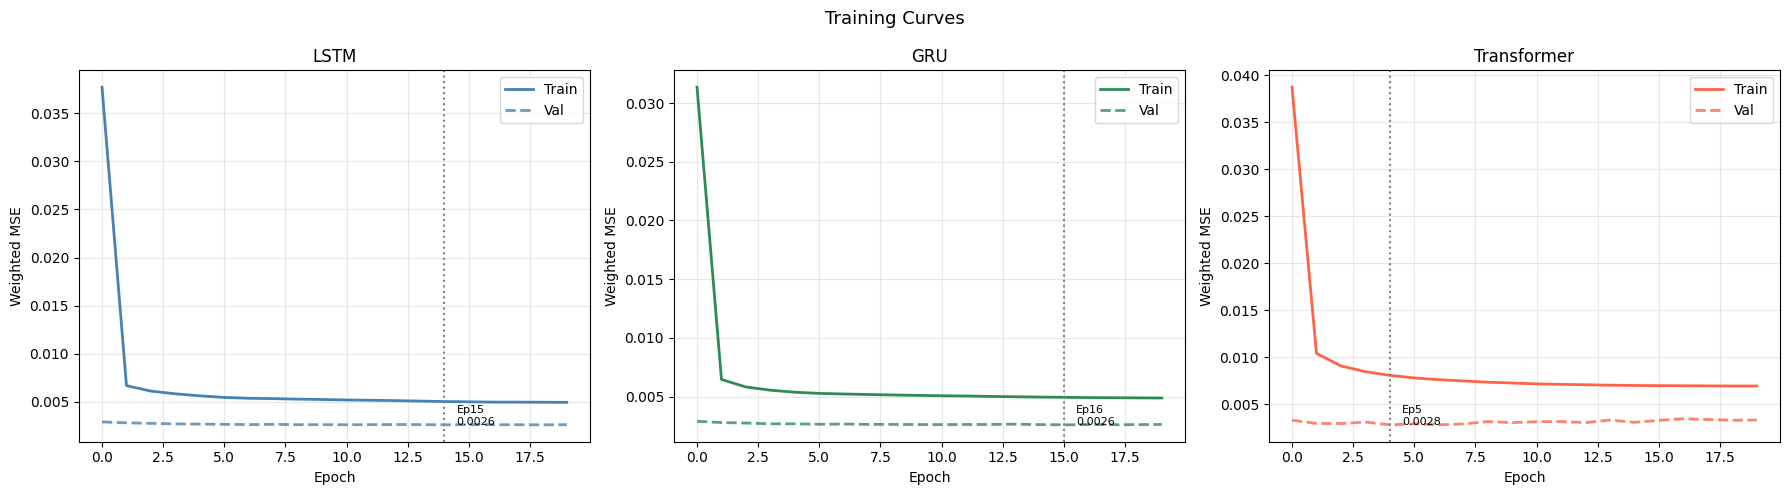

In [21]:
# ============================================================
# Training curves
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
runs = [("LSTM", lstm_tr, lstm_vl, "steelblue"),
       ("GRU", gru_tr, gru_vl, "seagreen"),
       ("Transformer", trans_tr, trans_vl, "tomato")]
for ax, (name, tr, vl, color) in zip(axes, runs):
    ax.plot(tr, color=color, lw=2, label="Train")
    ax.plot(vl, color=color, lw=2, ls="--", alpha=0.8, label="Val")
    best = int(np.argmin(vl))
    ax.axvline(best, ls=":", color="gray")
    ax.text(best+0.5, vl[best], f"Ep{best+1}\n{vl[best]:.4f}", fontsize=8)
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.set_ylabel("Weighted MSE")
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Training Curves", fontsize=13)
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# ============================================================
# Test set evaluation — open-loop accuracy (R², RMSE, per-horizon)
# ============================================================

def evaluate(loader, model, name):
    model.eval()
    P_list, T_list = [], []
    with torch.inference_mode():
        for x, s0, fu, y in loader:
            P_list.append(model(x.to(device), s0.to(device), fu.to(device)).cpu().numpy())
            T_list.append(y.numpy())
    P = np.concatenate(P_list); Y = np.concatenate(T_list)
    P_phys = scaler_S.inverse_transform(P.reshape(-1,2)).reshape(-1,H,2)
    Y_phys = scaler_S.inverse_transform(Y.reshape(-1,2)).reshape(-1,H,2)

    r2_ca = [r2_score(Y_phys[:,h,0], P_phys[:,h,0]) for h in range(H)]
    r2_t  = [r2_score(Y_phys[:,h,1], P_phys[:,h,1]) for h in range(H)]
    r2_ca_all = r2_score(Y_phys[:,:,0].ravel(), P_phys[:,:,0].ravel())
    r2_t_all  = r2_score(Y_phys[:,:,1].ravel(), P_phys[:,:,1].ravel())
    rmse_ca = np.sqrt(mean_squared_error(Y_phys[:,:,0].ravel(), P_phys[:,:,0].ravel()))
    rmse_t  = np.sqrt(mean_squared_error(Y_phys[:,:,1].ravel(), P_phys[:,:,1].ravel()))

    print(f"{'='*50}\n{name}")
    print(f"  CA_out — R²={r2_ca_all:.4f}  RMSE={rmse_ca:.5f} kmol/m³")
    print(f"  T_out  — R²={r2_t_all:.4f}  RMSE={rmse_t:.4f} K")
    return {"name":name, "P":P_phys, "Y":Y_phys, "r2_ca":r2_ca, "r2_t":r2_t,
            "r2_ca_all":r2_ca_all, "r2_t_all":r2_t_all, "rmse_ca":rmse_ca, "rmse_t":rmse_t}

lstm_res  = evaluate(test_loader, lstm_model,  "LSTM")
gru_res   = evaluate(test_loader, gru_model,   "GRU")
trans_res = evaluate(test_loader, trans_model, "Transformer")

LSTM
  CA_out — R²=0.9950  RMSE=0.03210 kmol/m³
  T_out  — R²=0.9994  RMSE=0.1661 K
GRU
  CA_out — R²=0.9950  RMSE=0.03216 kmol/m³
  T_out  — R²=0.9994  RMSE=0.1704 K
Transformer
  CA_out — R²=0.9943  RMSE=0.03432 kmol/m³
  T_out  — R²=0.9988  RMSE=0.2383 K


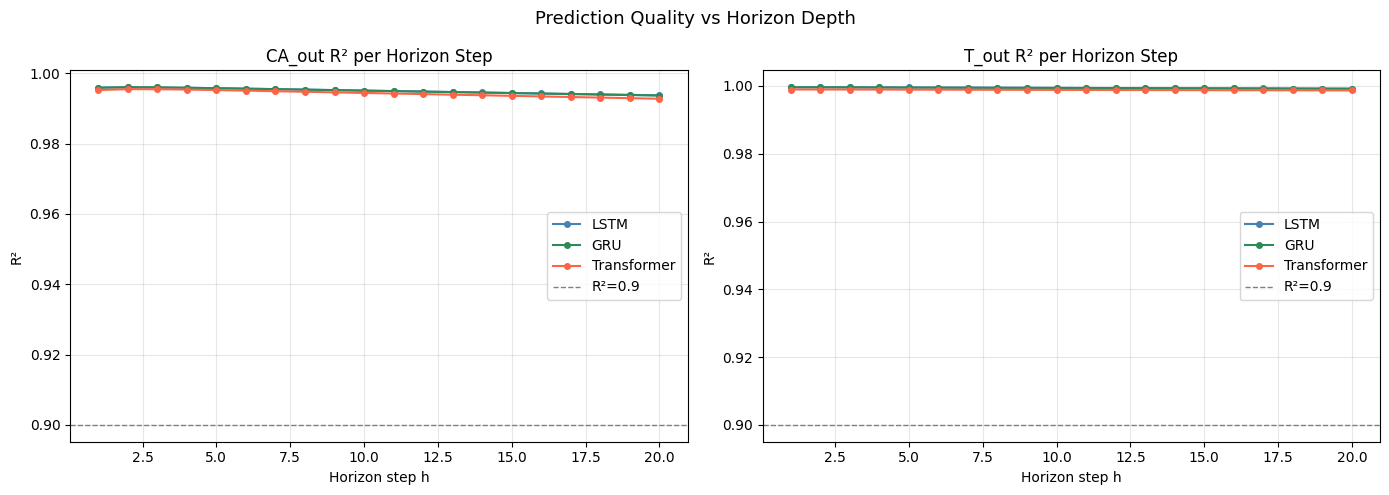

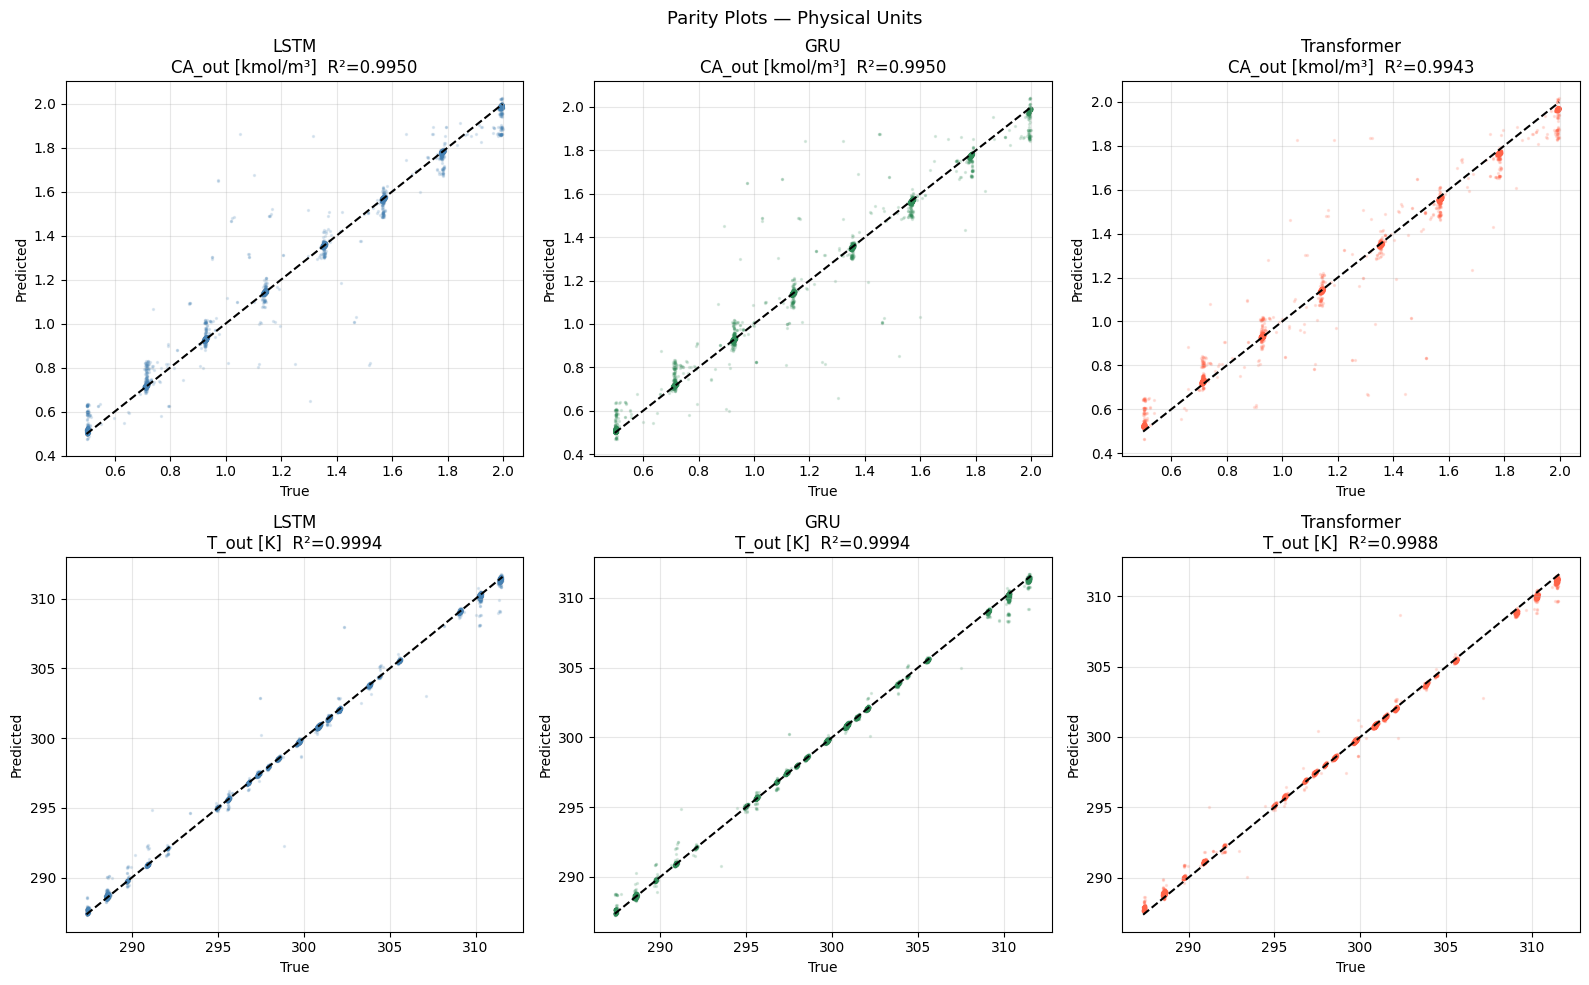

      Model  R²_CA   R²_T  RMSE_CA  RMSE_T
       LSTM 0.9950 0.9994  0.03210  0.1661
        GRU 0.9950 0.9994  0.03216  0.1704
Transformer 0.9943 0.9988  0.03432  0.2383


,Model,R²_CA,R²_T,RMSE_CA,RMSE_T
0,LSTM,0.9950,0.9994,0.03210,0.1661
1,GRU,0.9950,0.9994,0.03216,0.1704
2,Transformer,0.9943,0.9988,0.03432,0.2383


In [23]:
# ── Per-horizon-step R² ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14,5))
steps_h = np.arange(1, H+1)
colors3 = ["steelblue","seagreen","tomato"]
for res, col in zip([lstm_res, gru_res, trans_res], colors3):
    axes[0].plot(steps_h, res["r2_ca"], marker="o", ms=4, color=col, label=res["name"])
    axes[1].plot(steps_h, res["r2_t"],  marker="o", ms=4, color=col, label=res["name"])
for ax, title in zip(axes, ["CA_out R² per Horizon Step", "T_out R² per Horizon Step"]):
    ax.axhline(0.9, ls="--", color="gray", lw=1, label="R²=0.9")
    ax.set_xlabel("Horizon step h"); ax.set_ylabel("R²"); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Prediction Quality vs Horizon Depth", fontsize=13)
plt.tight_layout(); plt.savefig("r2_per_horizon.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Parity plots ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
labels = ["CA_out [kmol/m³]", "T_out [K]"]
for c, (res, col) in enumerate(zip([lstm_res, gru_res, trans_res], colors3)):
    for r in range(2):
        ax = axes[r, c]
        yt = res["Y"][:,:,r].ravel(); yp = res["P"][:,:,r].ravel()
        idx = np.random.choice(len(yt), min(10000,len(yt)), replace=False)
        ax.scatter(yt[idx], yp[idx], s=2, alpha=0.15, color=col)
        lo, hi = yt.min(), yt.max()
        ax.plot([lo,hi],[lo,hi],"k--",lw=1.5)
        r2 = res["r2_ca_all"] if r==0 else res["r2_t_all"]
        ax.set_title(f"{res['name']}\n{labels[r]}  R²={r2:.4f}")
        ax.set_xlabel("True"); ax.set_ylabel("Predicted"); ax.grid(alpha=0.3)
plt.suptitle("Parity Plots — Physical Units", fontsize=13)
plt.tight_layout(); plt.savefig("parity_plots.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Summary table ───────────────────────────────────────────────
comparison = pd.DataFrame([{
    "Model": r["name"], "R²_CA": round(r["r2_ca_all"],4), "R²_T": round(r["r2_t_all"],4),
    "RMSE_CA": round(r["rmse_ca"],5), "RMSE_T": round(r["rmse_t"],4),
} for r in [lstm_res, gru_res, trans_res]])
print(comparison.to_string(index=False))
comparison

## 5. Load Best Checkpoints

In [24]:
def load_best(ModelClass, filename, **kwargs):
    m = ModelClass(**kwargs).to(device)
    ckpt = torch.load(os.path.join(SAVE_DIR, filename), map_location=device)
    m.load_state_dict(ckpt["state"])
    m.eval()
    print(f"✓ Loaded {filename}")
    return m

lstm_model  = load_best(LSTMPredictor, "lstm_best.pt", num_layers=2)
gru_model   = load_best(GRUPredictor, "gru_best.pt", num_layers=2)
trans_model = load_best(TransformerPredictor, "transformer_best.pt")

✓ Loaded lstm_best.pt
✓ Loaded gru_best.pt
✓ Loaded transformer_best.pt


## 6. CSTR Plant (RK4, dt=1s)

In [25]:
def cstr_deriv(CA, T, CAin, Tin, TC):
    F=1.0; V=1.0; k0=1e6; E=5e4; R=8.314
    dH=-4.5e4; rho=1000.0; Cp=4180.0; UA=1.5e6
    k = k0*np.exp(-E/(R*max(T,250.0))); rA = k*max(CA,0.0)
    dCA = (F/V)*(CAin-CA) - rA
    dT = (F/V)*(Tin-T) + (-dH/(rho*Cp))*rA + (UA/(rho*Cp*V))*(TC-T)
    return np.array([dCA, dT])

def rk4_step(state, u, dt=1.0):
    k1 = cstr_deriv(*state, *u)
    k2 = cstr_deriv(*(state+0.5*dt*k1), *u)
    k3 = cstr_deriv(*(state+0.5*dt*k2), *u)
    k4 = cstr_deriv(*(state+dt*k3), *u)
    ns = state + (dt/6)*(k1+2*k2+2*k3+k4)
    ns[0] = max(ns[0], 0.0)
    return ns

SS_CA_IN = float(scaler_X.mean_[INPUT_COLS.index("CA_in_kmol_m3")])
SS_TIN   = float(scaler_X.mean_[INPUT_COLS.index("Tin_K")])
SS_TC    = float(scaler_X.mean_[INPUT_COLS.index("TC_K")])
SS_CA    = float(scaler_S.mean_[STATE_COLS.index("CA_out_kmol_m3")])
SS_T     = float(scaler_S.mean_[STATE_COLS.index("T_out_K")])

_s = np.array([SS_CA, SS_T])
for _ in range(2000):
    _s = rk4_step(_s, [SS_CA_IN, SS_TIN, SS_TC])
print(f"Steady-state check — CA_out={_s[0]:.4f} (target {SS_CA:.4f})  "
      f"T_out={_s[1]:.2f} (target {SS_T:.2f})")

Steady-state check — CA_out=1.2299 (target 1.2298)  T_out=299.38 (target 299.39)


## 7. NMPC Cost Function — Exact Autograd Gradients

This is the fix for the earlier setpoint-tracking failure: SLSQP's default
finite-difference gradient step (~1.49e-8, an absolute perturbation) is far
too small relative to physical-unit decision variables (CA_in~O(1), TC~O(300))
and gets lost to float32 precision — SLSQP was effectively blind to the
model's true learned sensitivity. Supplying exact gradients via
`torch.autograd` removes this numerical blindness entirely.

In [26]:
X_mean_t  = torch.tensor(scaler_X.mean_,  dtype=torch.float32, device=device)
X_scale_t = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
S_mean_t  = torch.tensor(scaler_S.mean_,  dtype=torch.float32, device=device)
S_scale_t = torch.tensor(scaler_S.scale_, dtype=torch.float32, device=device)
W_STATE_t = torch.tensor(W_STATE, dtype=torch.float32, device=device)
W_DERIV_t = torch.tensor(W_DERIV, dtype=torch.float32, device=device)


def nmpc_cost_and_grad(mv_flat, model, x_buf_phys, s0_phys, setpoint, u_prev, Tin_k, int_err):
    mv_t = torch.tensor(mv_flat, dtype=torch.float32, device=device, requires_grad=True)
    mv2 = mv_t.view(Nc, 2)

    full = torch.cat([mv2, mv2[-1:].expand(Np - Nc, -1)], dim=0)   # move-blocking

    x_sc  = torch.tensor(scaler_X.transform(x_buf_phys), dtype=torch.float32,
                        device=device).unsqueeze(0)
    s0_sc = torch.tensor(scaler_S.transform(s0_phys.reshape(1,-1))[0], dtype=torch.float32,
                        device=device).unsqueeze(0)

    Tin_col = torch.full((Np, 1), float(Tin_k), device=device)
    future_phys = torch.cat([full[:, 0:1], Tin_col, full[:, 1:2]], dim=1)
    future_sc = ((future_phys - X_mean_t) / X_scale_t).unsqueeze(0)

    pred_sc = model(x_sc, s0_sc, future_sc)
    pred_phys = pred_sc[0] * S_scale_t + S_mean_t

    setpoint_t = torch.tensor(setpoint + int_err, dtype=torch.float32, device=device)
    e = setpoint_t - pred_phys
    J_track = torch.sum(W_STATE_t * torch.sum(e**2, dim=0))

    prev = torch.tensor(u_prev, dtype=torch.float32, device=device)
    J_move = torch.tensor(0.0, device=device)
    for i in range(Nc):
        J_move = J_move + torch.sum(W_DERIV_t * (mv2[i] - prev)**2)
        prev = mv2[i]

    J = J_track + J_move
    J.backward()

    grad = mv_t.grad.detach().cpu().numpy().astype(np.float64)
    return float(J.item()), grad


SLSQP_BOUNDS = [(MV_MIN[j%2], MV_MAX[j%2]) for j in range(Nc*2)]
print("✓ Autograd NMPC cost function defined")

✓ Autograd NMPC cost function defined


## 8. Closed-Loop Simulation

In [27]:
def run_nmpc(model, model_name, setpoints_arr, disturbances=None, verbose=False):
    state = np.array([SS_CA, SS_T])
    x_buf = np.tile([SS_CA_IN, SS_TIN, SS_TC], (T, 1)).astype(float)
    u_prev = np.array([SS_CA_IN, SS_TC])
    int_err = np.zeros(2)

    Y_log = np.zeros((N_SIM,2)); U_log = np.zeros((N_SIM,2)); T_log = np.zeros(N_SIM)

    for k in range(N_SIM):
        Tin_k = float(disturbances[k]) if disturbances is not None else SS_TIN
        sp_k = setpoints_arr[k]

        u_plant = np.array([u_prev[0], Tin_k, u_prev[1]])
        state = rk4_step(state, u_plant)
        y_meas = state + np.random.randn(2) * np.array([0.001, 0.05])
        Y_log[k] = y_meas; U_log[k] = u_prev

        t0 = time.perf_counter()
        res = minimize(nmpc_cost_and_grad, x0=np.tile(u_prev, Nc).astype(np.float64),
                       args=(model, x_buf, y_meas, sp_k, u_prev, Tin_k, int_err),
                       jac=True, method="SLSQP", bounds=SLSQP_BOUNDS,
                       options={"maxiter":150, "ftol":1e-8, "disp":False})
        T_log[k] = time.perf_counter() - t0

        mv = res.x.reshape(Nc, 2)
        full = np.vstack([mv, np.tile(mv[-1], (Np-Nc,1))])
        u_new = np.clip(full[0], MV_MIN, MV_MAX)

        err = sp_k - y_meas
        int_err = np.clip(int_err + KI*err, -INT_CLAMP, INT_CLAMP)

        x_buf = np.vstack([x_buf[1:], [u_new[0], Tin_k, u_new[1]]])
        u_prev = u_new

        if verbose and (k+1) % 50 == 0:
            print(f"  [{model_name}] step {k+1}/{N_SIM} | CA={y_meas[0]:.4f} sp={sp_k[0]:.4f} | "
                  f"T={y_meas[1]:.2f} sp={sp_k[1]:.2f} | solve={T_log[k]*1000:.1f}ms")

    IAE_CA = float(np.sum(np.abs(Y_log[:,0]-setpoints_arr[:,0])))
    IAE_T  = float(np.sum(np.abs(Y_log[:,1]-setpoints_arr[:,1])))
    return {"name":model_name, "Y":Y_log, "U":U_log, "SP":setpoints_arr,
            "times":T_log, "IAE_CA":IAE_CA, "IAE_T":IAE_T}

## 9. Define Test Scenarios

In [28]:
steps = np.arange(N_SIM)

SP_servo = np.column_stack([
    np.where(steps<50, SS_CA, np.where(steps<120, SS_CA+0.15, SS_CA+0.25)),
    np.where(steps<50, SS_T,  np.where(steps<120, SS_T+1.0,  SS_T+1.5)),
])
TIN_dist = np.where(steps<50, SS_TIN, np.where(steps<120, SS_TIN+1.0, SS_TIN+2.0))
SP_reg = np.tile([SS_CA, SS_T], (N_SIM,1))

controllers = [(lstm_model,"LSTM"), (gru_model,"GRU"), (trans_model,"Transformer")]
print("Scenarios defined ✓")

Scenarios defined ✓


## 10. The Decisive Test — Multi-Seed Closed-Loop Comparison

This settles whether Transformer's higher IAE is a genuine architectural
weakness or noise compounding over 200 recursive control steps. If IAE is
consistently ~2x worse across all seeds with small spread, it's real. If
it swings wildly between seeds, it's noise-sensitivity — still worth
reporting, just framed differently.

In [29]:
N_SEEDS = 5
iae_ca_results = {name: [] for _, name in controllers}
iae_t_results  = {name: [] for _, name in controllers}

for seed in range(1, N_SEEDS+1):
    np.random.seed(seed)
    for model, name in controllers:
        # CRITICAL FIX: Force training mode so cuDNN retains backward graphs for SLSQP
        model.train() 
        
        # Explicitly freeze model weights so gradients are only computed for MVs
        for param in model.parameters():
            param.requires_grad = False
            
        r = run_nmpc(model, name, SP_servo, verbose=False)
        iae_ca_results[name].append(r["IAE_CA"])
        iae_t_results[name].append(r["IAE_T"])
    print(f"Seed {seed} done")

print(f"\n{'='*65}")
print(f"{'IAE_CA across ' + str(N_SEEDS) + ' seeds — Servo Test':^65}")
print(f"{'='*65}")
for name, vals in iae_ca_results.items():
    vals = np.array(vals)
    print(f"{name:12s} | mean={vals.mean():.4f}  std={vals.std():.4f}  "
          f"min={vals.min():.4f}  max={vals.max():.4f}  "
          f"cv={vals.std()/vals.mean()*100:.1f}%")

print(f"\n{'='*65}")
print(f"{'IAE_T across ' + str(N_SEEDS) + ' seeds — Servo Test':^65}")
print(f"{'='*65}")
for name, vals in iae_t_results.items():
    vals = np.array(vals)
    print(f"{name:12s} | mean={vals.mean():.2f}  std={vals.std():.2f}  "
          f"min={vals.min():.2f}  max={vals.max():.2f}  "
          f"cv={vals.std()/vals.mean()*100:.1f}%")

Seed 1 done
Seed 2 done
Seed 3 done
Seed 4 done
Seed 5 done

               IAE_CA across 5 seeds — Servo Test                
LSTM         | mean=1.5372  std=0.0803  min=1.4789  max=1.6959  cv=5.2%
GRU          | mean=1.2653  std=0.0483  min=1.1854  max=1.3176  cv=3.8%
Transformer  | mean=2.7821  std=0.3931  min=2.2917  max=3.3993  cv=14.1%

                IAE_T across 5 seeds — Servo Test                
LSTM         | mean=13.42  std=0.63  min=12.72  max=14.22  cv=4.7%
GRU          | mean=13.23  std=0.35  min=12.77  max=13.68  cv=2.7%
Transformer  | mean=17.46  std=0.46  min=16.82  max=17.95  cv=2.6%


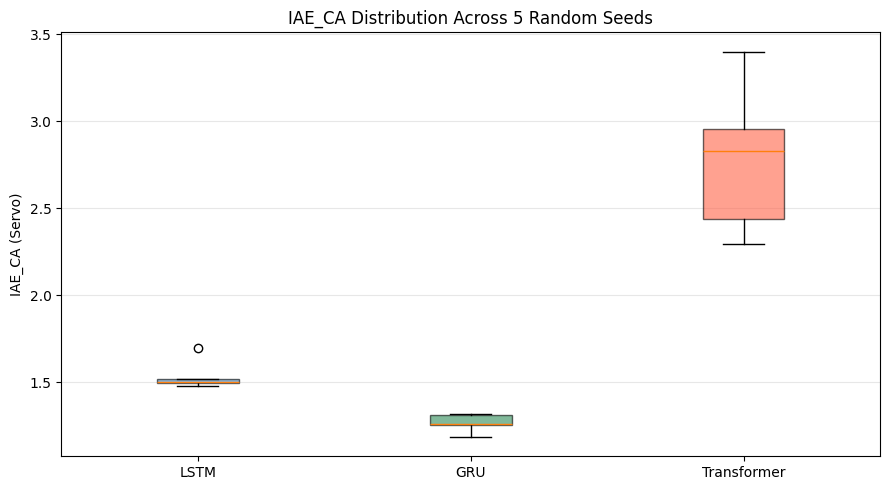

In [30]:
fig, ax = plt.subplots(figsize=(9,5))
names = list(iae_ca_results.keys())
data = [iae_ca_results[n] for n in names]
bp = ax.boxplot(data, labels=names, patch_artist=True)
colors = ["steelblue","seagreen","tomato"]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_ylabel("IAE_CA (Servo)")
ax.set_title(f"IAE_CA Distribution Across {N_SEEDS} Random Seeds")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("multiseed_iae_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Real-Time Readiness — Solve Time Benchmark

Plant sampling time is 1.0s — for genuine real-time deployment, every
control step (measure → solve → apply) must comfortably finish within
that budget.

In [31]:
def benchmark_solve_time(model, model_name, n_trials=50):
    x_buf_b = np.tile([SS_CA_IN, SS_TIN, SS_TC], (T,1)).astype(float)
    u_prev_b = np.array([SS_CA_IN, SS_TC])
    state_b = np.array([SS_CA+0.1, SS_T+0.5])
    int_err_b = np.zeros(2)

    times = []
    for _ in range(n_trials):
        t0 = time.perf_counter()
        res = minimize(nmpc_cost_and_grad, x0=np.tile(u_prev_b, Nc).astype(np.float64),
                       args=(model, x_buf_b, state_b, SP_servo[100], u_prev_b, SS_TIN, int_err_b),
                       jac=True, method="SLSQP", bounds=SLSQP_BOUNDS,
                       options={"maxiter":150, "ftol":1e-8, "disp":False})
        times.append(time.perf_counter() - t0)
    times = np.array(times)
    budget_ok = times.max() < 1.0
    print(f"{model_name:12s} | mean={times.mean()*1000:7.2f}ms  "
          f"p95={np.percentile(times,95)*1000:7.2f}ms  "
          f"max={times.max()*1000:7.2f}ms  "
          f"{'✓ within 1s budget' if budget_ok else '✗ EXCEEDS 1s budget'}")
    return times

print(f"{'='*70}")
print(f"{'Real-Time Solve Time Benchmark (1.0s budget)':^70}")
print(f"{'='*70}")
t_lstm  = benchmark_solve_time(lstm_model,  "LSTM")
t_gru   = benchmark_solve_time(gru_model,   "GRU")
t_trans = benchmark_solve_time(trans_model, "Transformer")

             Real-Time Solve Time Benchmark (1.0s budget)             
LSTM         | mean= 267.04ms  p95= 344.90ms  max= 471.87ms  ✓ within 1s budget
GRU          | mean= 286.87ms  p95= 432.74ms  max= 519.66ms  ✓ within 1s budget
Transformer  | mean= 373.98ms  p95= 560.51ms  max= 904.11ms  ✓ within 1s budget


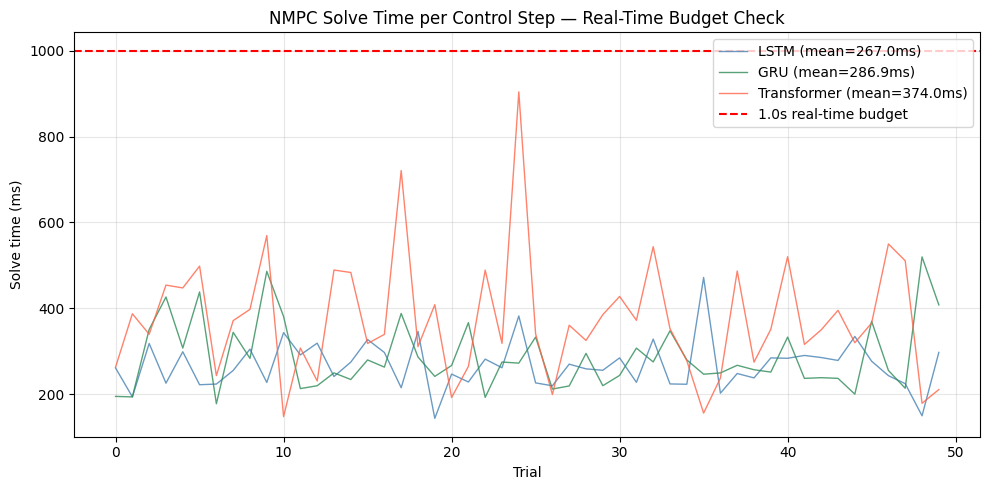

In [32]:
fig, ax = plt.subplots(figsize=(10,5))
for t_arr, name, c in zip([t_lstm, t_gru, t_trans], ["LSTM","GRU","Transformer"], colors):
    ax.plot(t_arr*1000, color=c, lw=1, alpha=0.8, label=f"{name} (mean={t_arr.mean()*1000:.1f}ms)")
ax.axhline(1000, color="red", ls="--", lw=1.5, label="1.0s real-time budget")
ax.set_xlabel("Trial"); ax.set_ylabel("Solve time (ms)")
ax.set_title("NMPC Solve Time per Control Step — Real-Time Budget Check")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("realtime_solve_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Full Servo + Regulatory Run (Final Numbers)
With determinism maximized and gradients fixed, run the complete
comparison once more for your final reported results.

In [33]:
np.random.seed(SEED)
servo_results = [run_nmpc(m, n, SP_servo, verbose=True) for m, n in controllers]
reg_results   = [run_nmpc(m, n, SP_reg, TIN_dist, verbose=True) for m, n in controllers]

print(f"\n{'='*70}")
print(f"{'Final NMPC Performance Summary':^70}")
print(f"{'='*70}")
print(f"{'Model':<14}{'Servo IAE_CA':>13}{'Servo IAE_T':>13}{'Reg IAE_CA':>12}{'Reg IAE_T':>11}")
print("-"*70)
for s, r in zip(servo_results, reg_results):
    print(f"{s['name']:<14}{s['IAE_CA']:>13.3f}{s['IAE_T']:>13.3f}{r['IAE_CA']:>12.3f}{r['IAE_T']:>11.3f}")
print("="*70)

  [LSTM] step 50/200 | CA=1.2296 sp=1.2298 | T=299.37 sp=299.39 | solve=82.5ms
  [LSTM] step 100/200 | CA=1.3826 sp=1.3798 | T=300.36 sp=300.39 | solve=136.8ms
  [LSTM] step 150/200 | CA=1.4509 sp=1.4798 | T=300.90 sp=300.89 | solve=168.0ms
  [LSTM] step 200/200 | CA=1.4869 sp=1.4798 | T=300.99 sp=300.89 | solve=106.4ms
  [GRU] step 50/200 | CA=1.2300 sp=1.2298 | T=299.32 sp=299.39 | solve=161.7ms
  [GRU] step 100/200 | CA=1.3876 sp=1.3798 | T=300.45 sp=300.39 | solve=155.5ms
  [GRU] step 150/200 | CA=1.4967 sp=1.4798 | T=300.89 sp=300.89 | solve=121.3ms
  [GRU] step 200/200 | CA=1.4885 sp=1.4798 | T=300.92 sp=300.89 | solve=183.8ms
  [Transformer] step 50/200 | CA=1.2505 sp=1.2298 | T=299.35 sp=299.39 | solve=203.1ms
  [Transformer] step 100/200 | CA=1.3187 sp=1.3798 | T=300.50 sp=300.39 | solve=151.4ms
  [Transformer] step 150/200 | CA=1.4650 sp=1.4798 | T=300.97 sp=300.89 | solve=172.1ms
  [Transformer] step 200/200 | CA=1.4718 sp=1.4798 | T=300.98 sp=300.89 | solve=228.7ms
  [LSTM]


Generating plots for [LSTM] (servo test)...


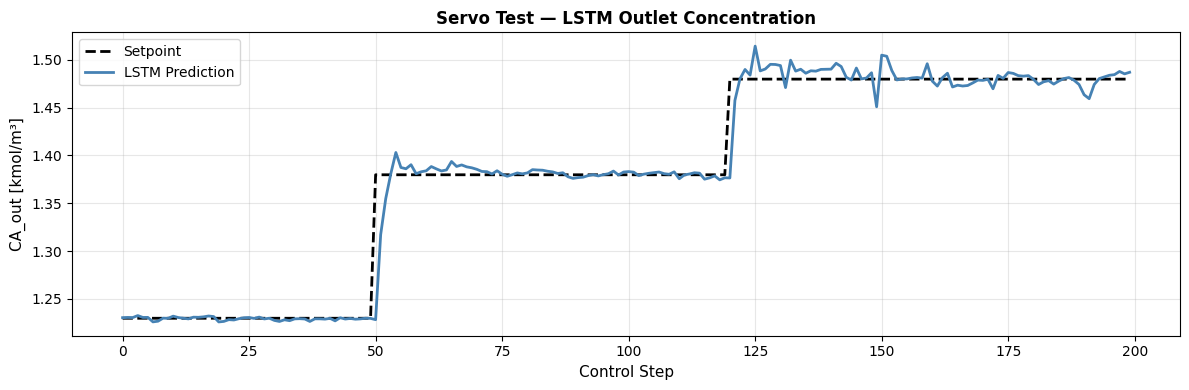

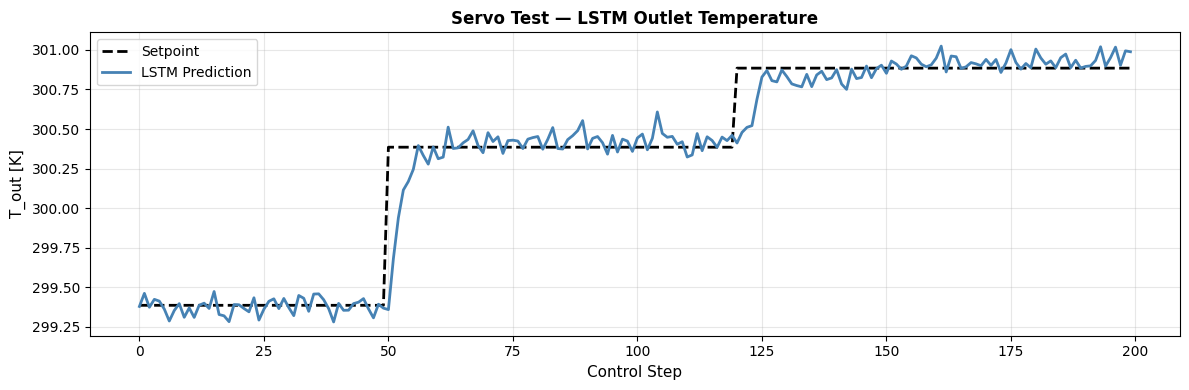

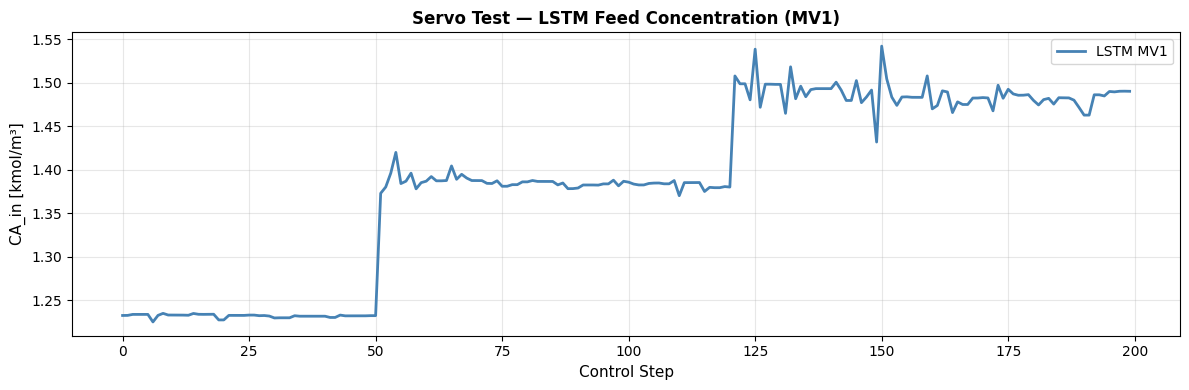

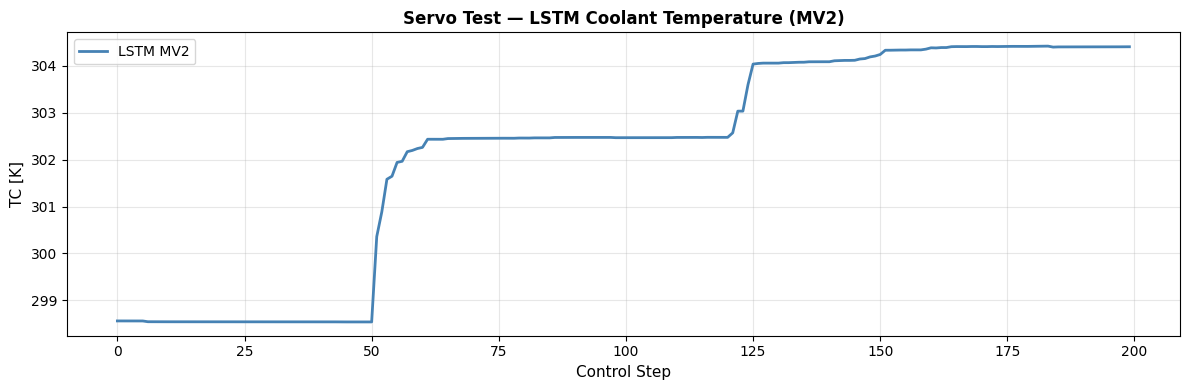

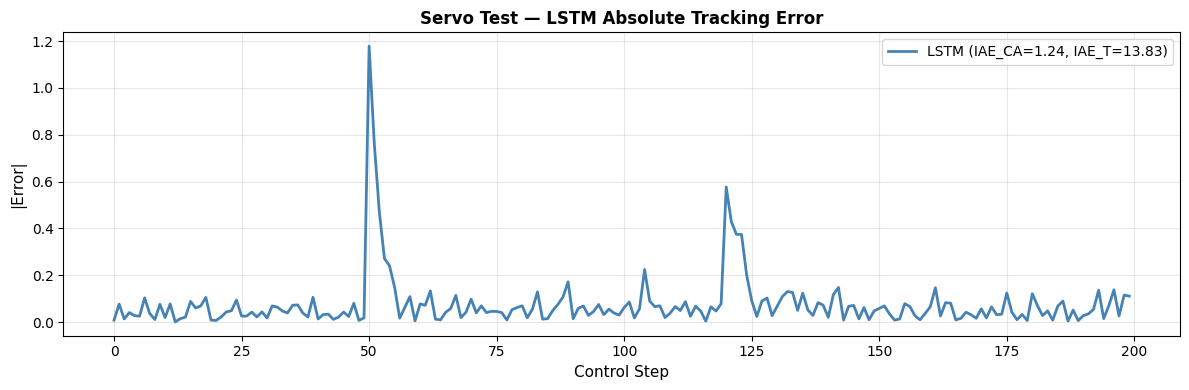

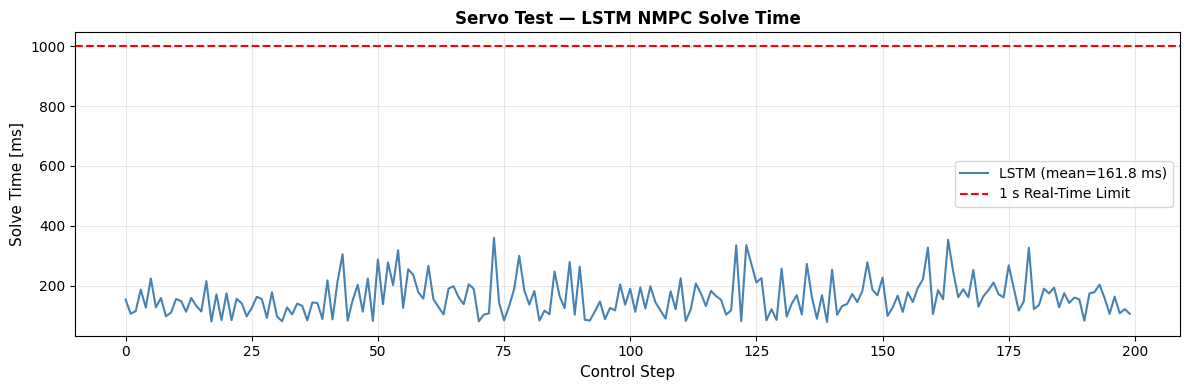


Generating plots for [GRU] (servo test)...


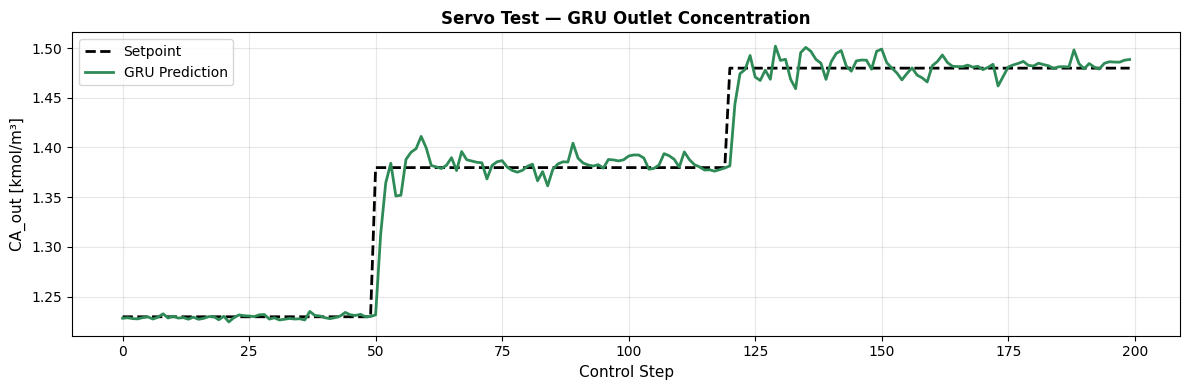

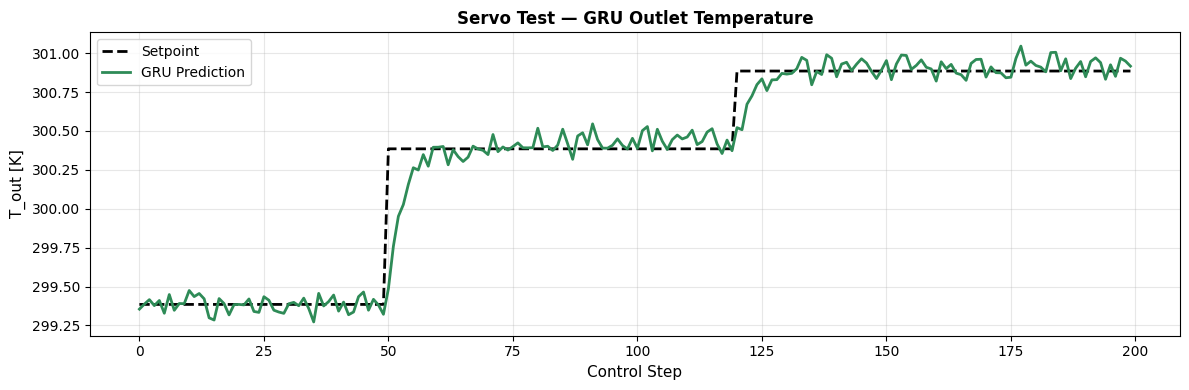

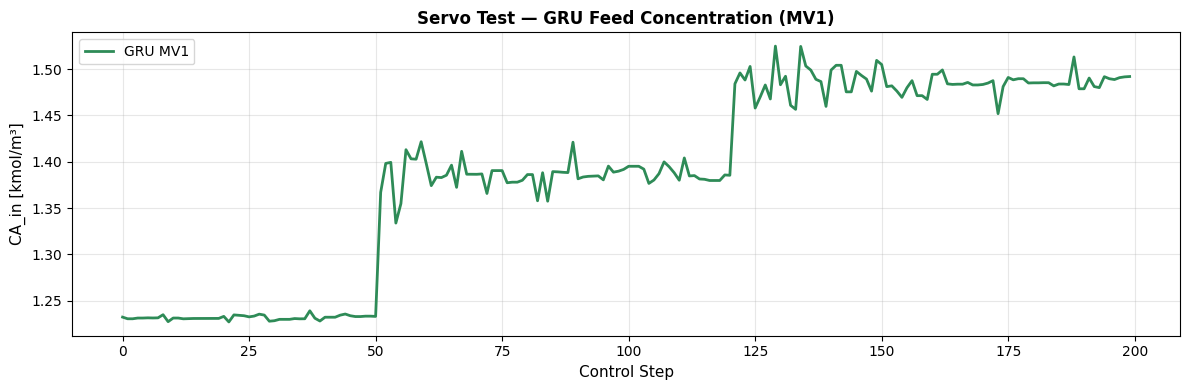

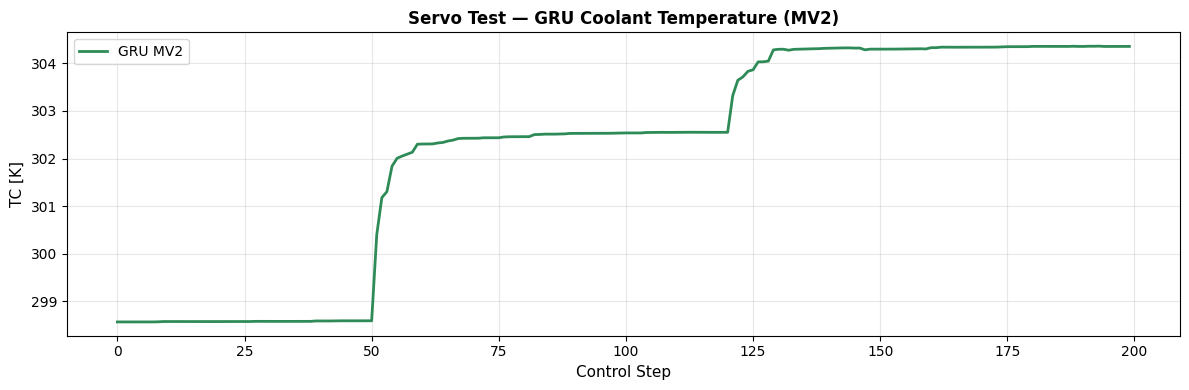

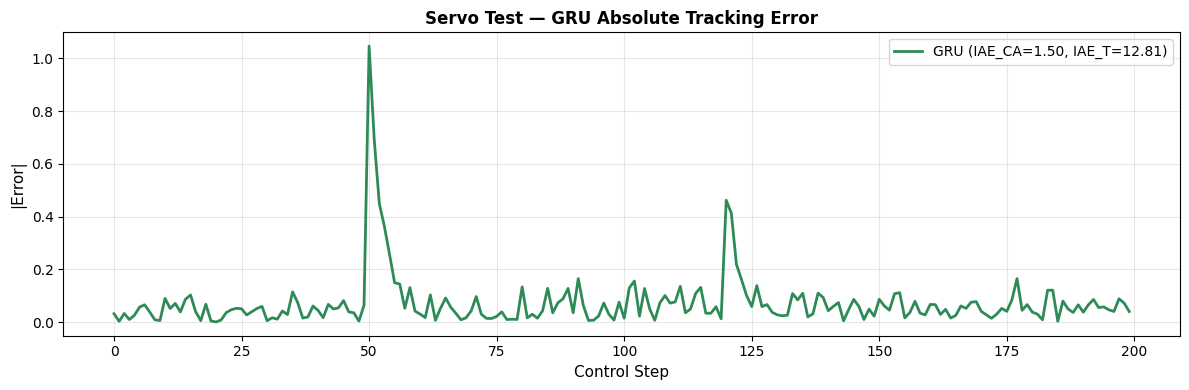

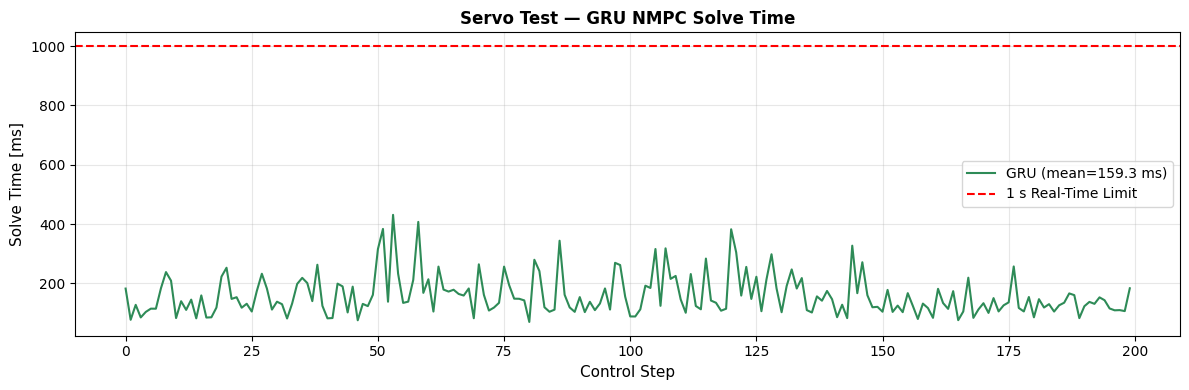


Generating plots for [Transformer] (servo test)...


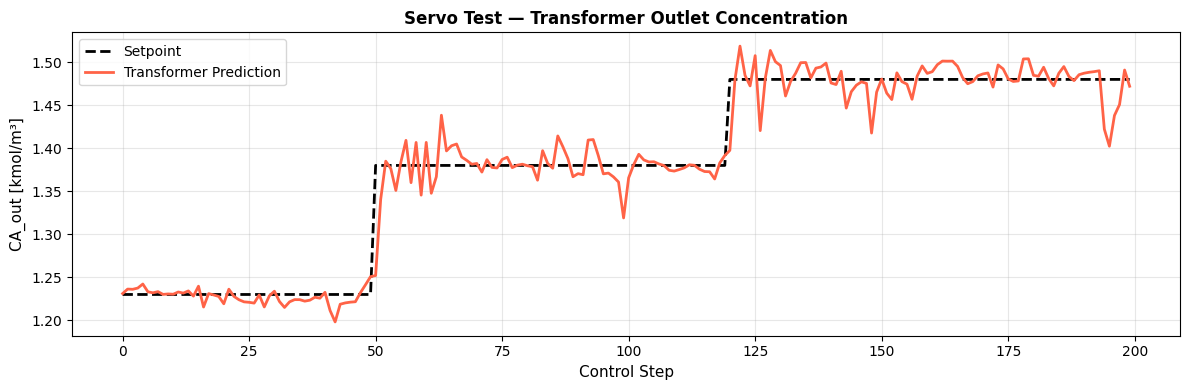

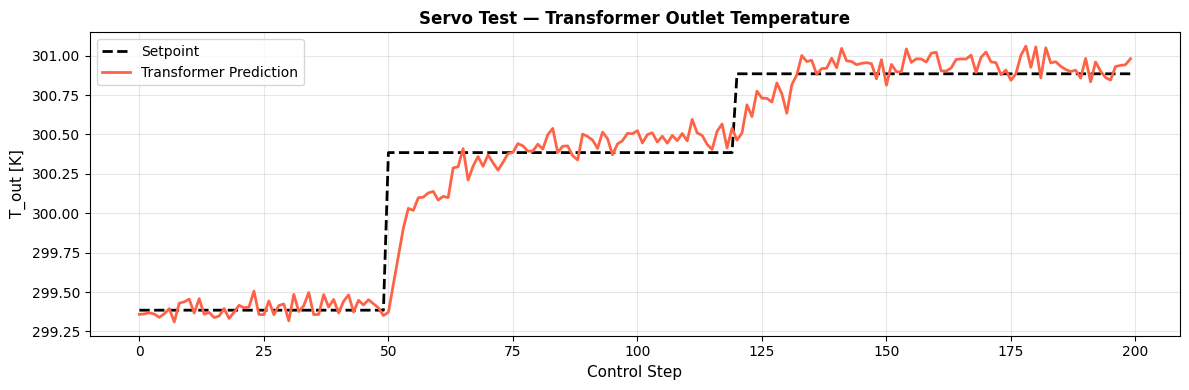

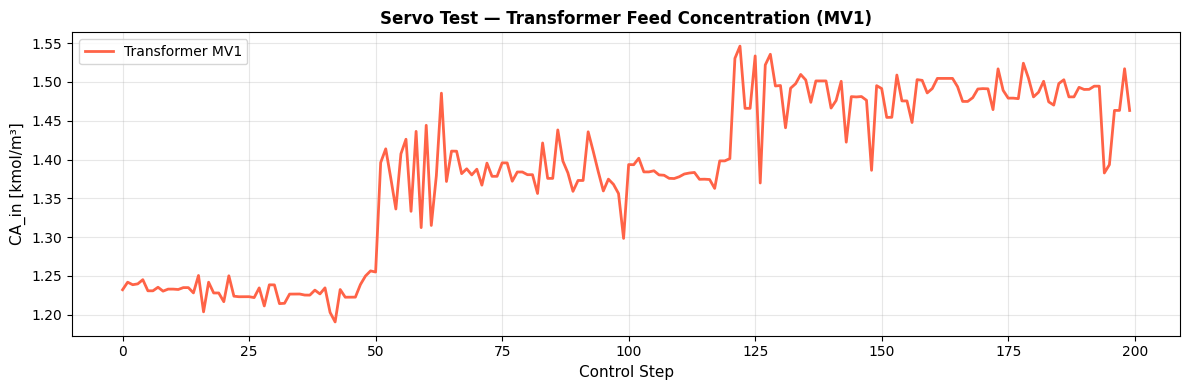

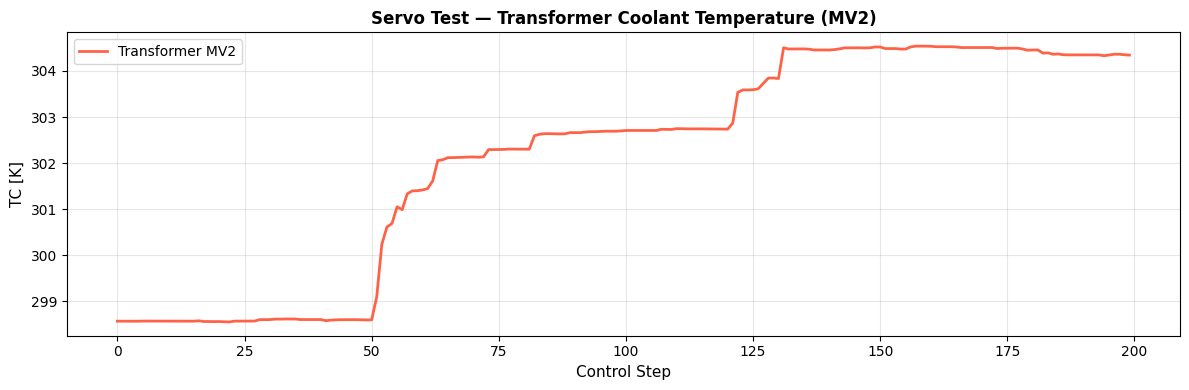

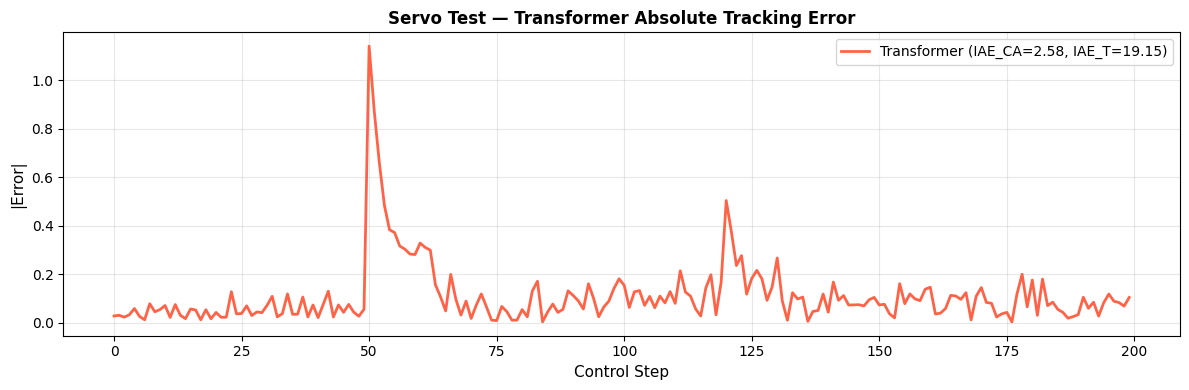

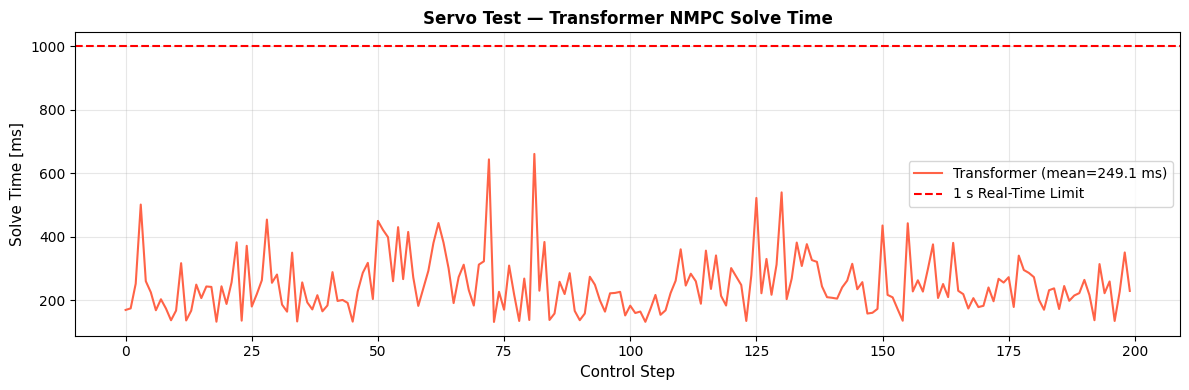


Generating plots for [LSTM] (reg test)...


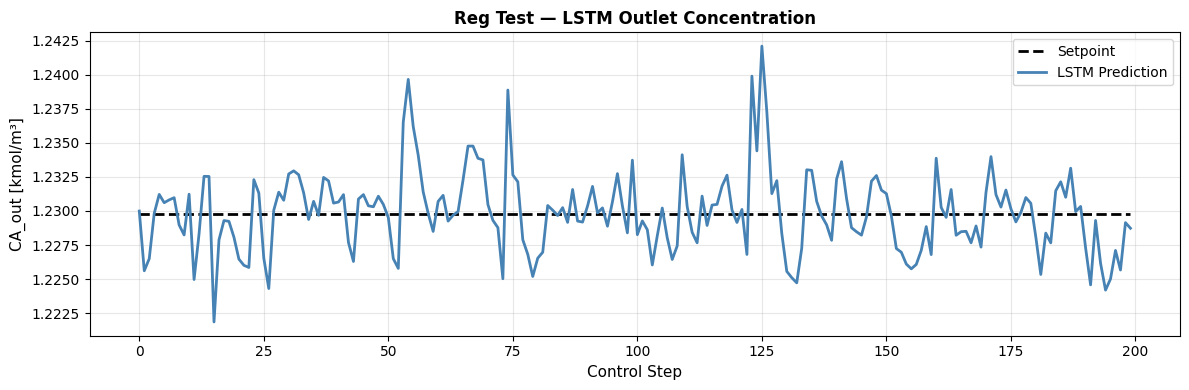

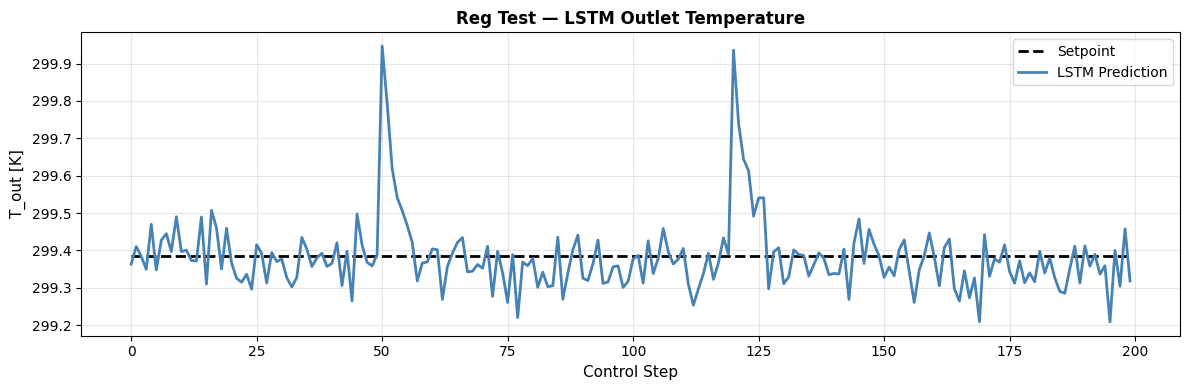

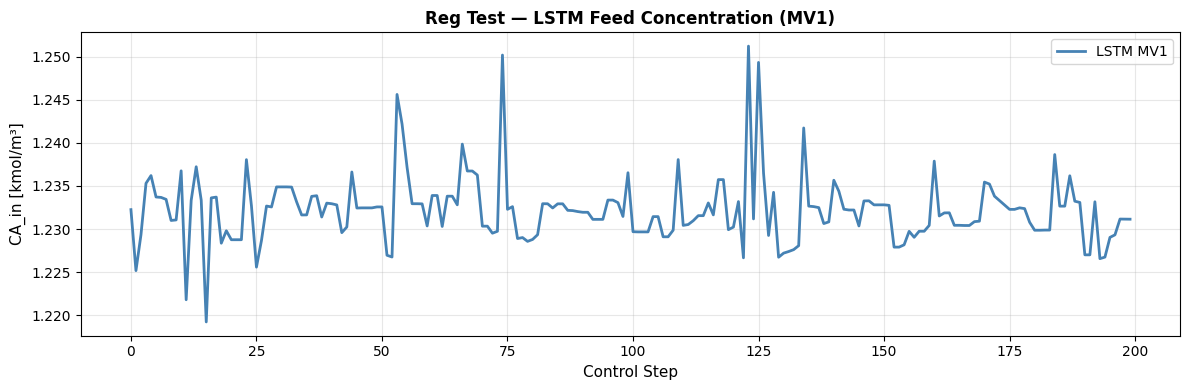

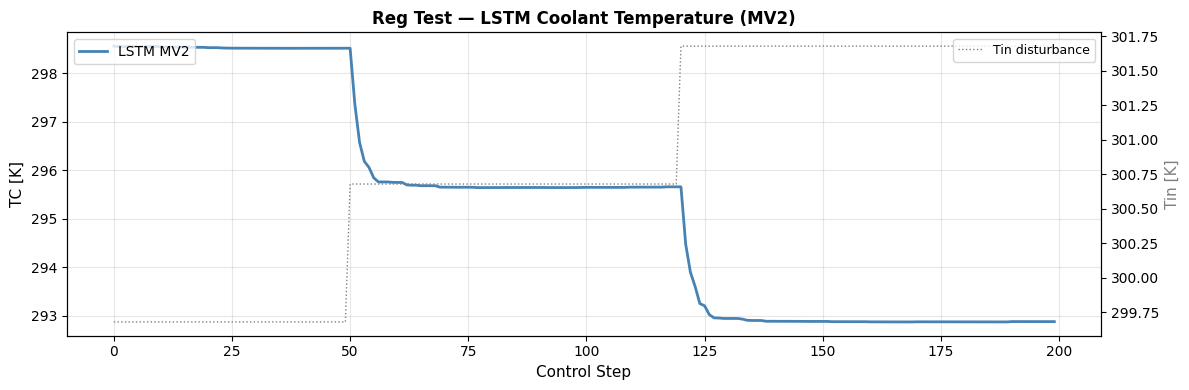

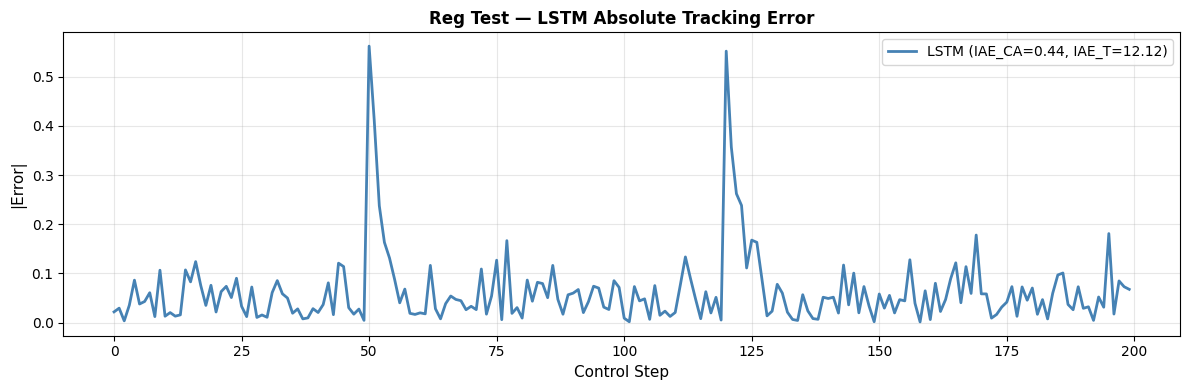

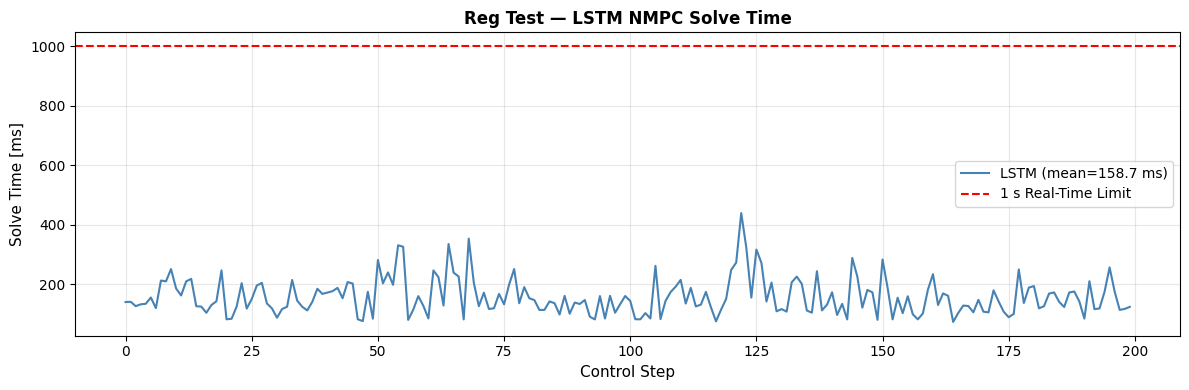


Generating plots for [GRU] (reg test)...


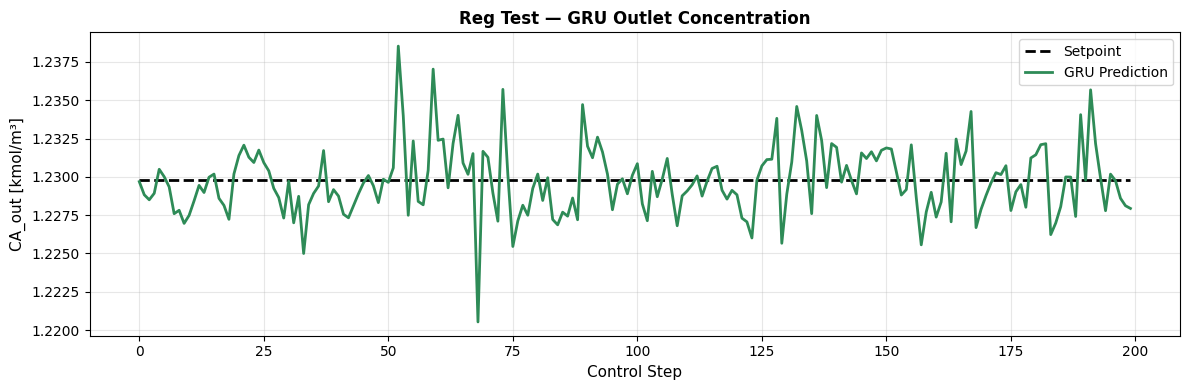

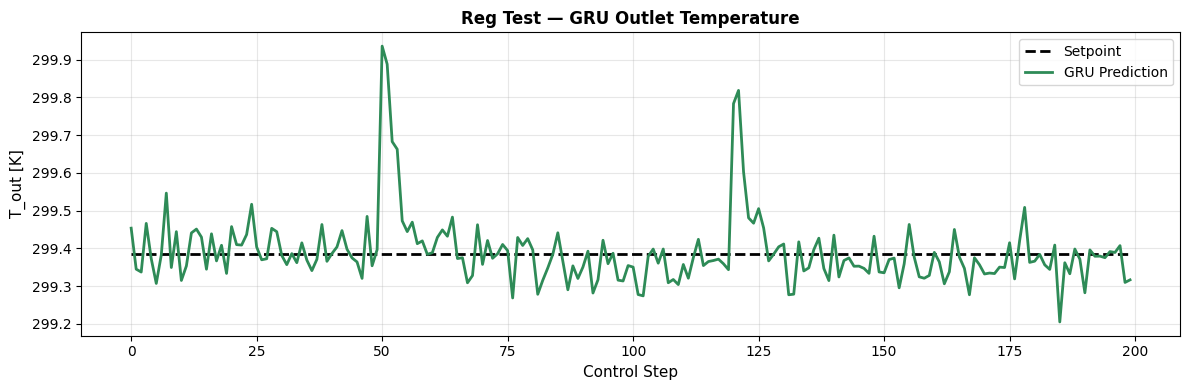

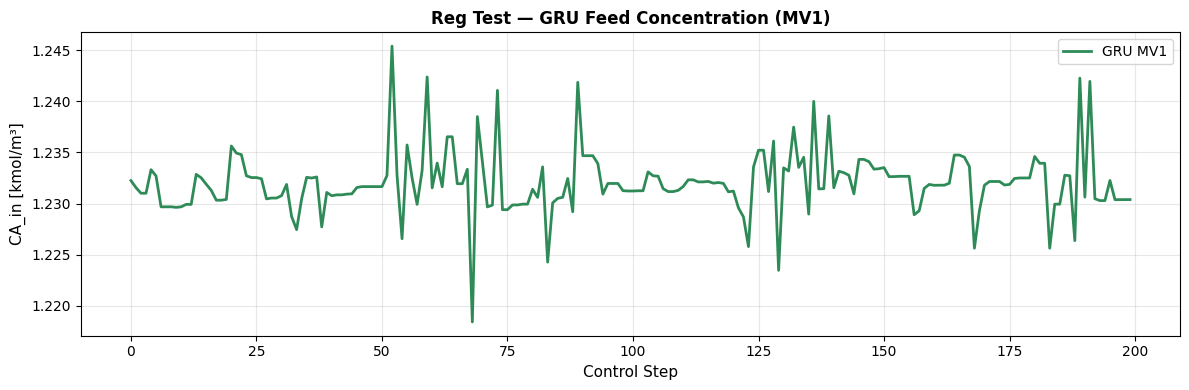

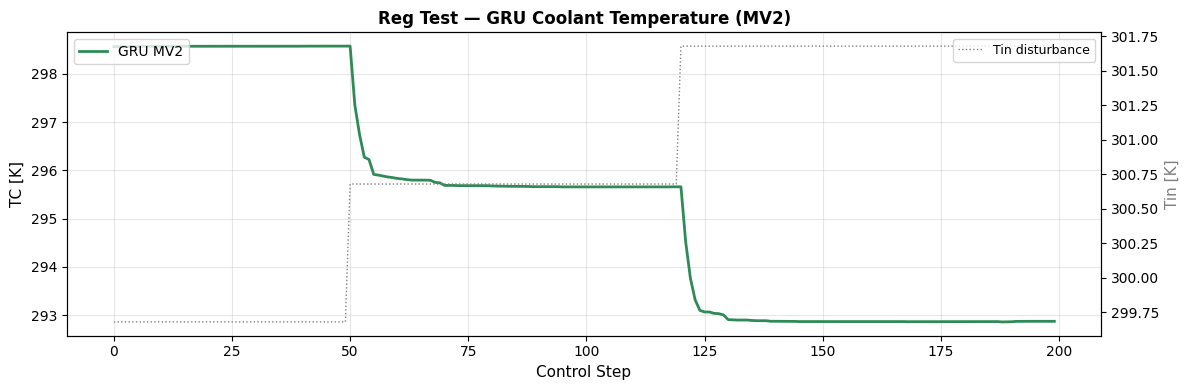

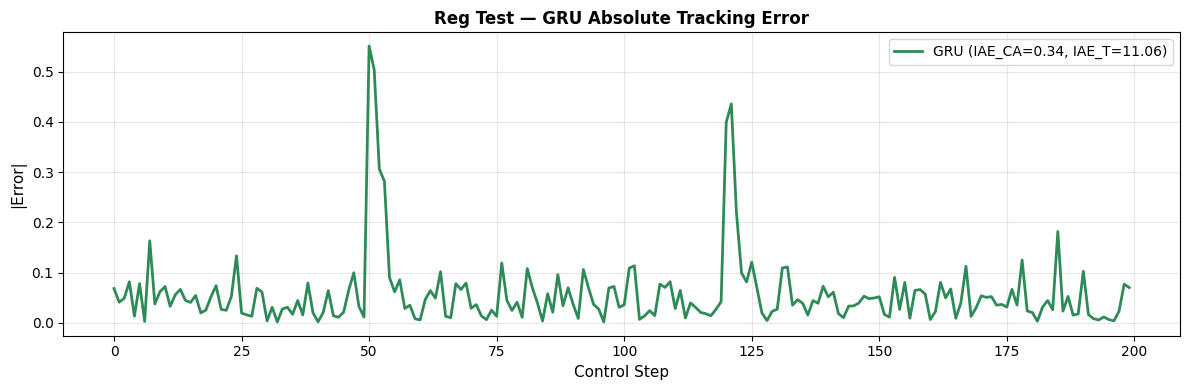

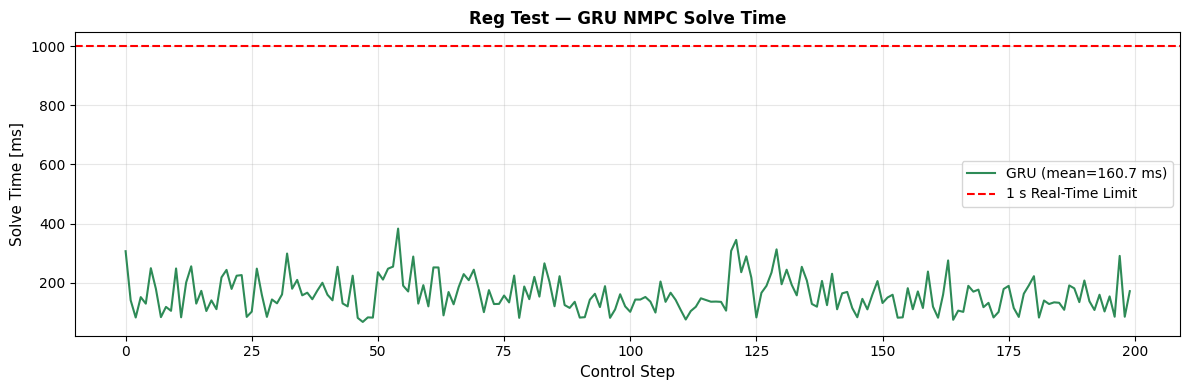


Generating plots for [Transformer] (reg test)...


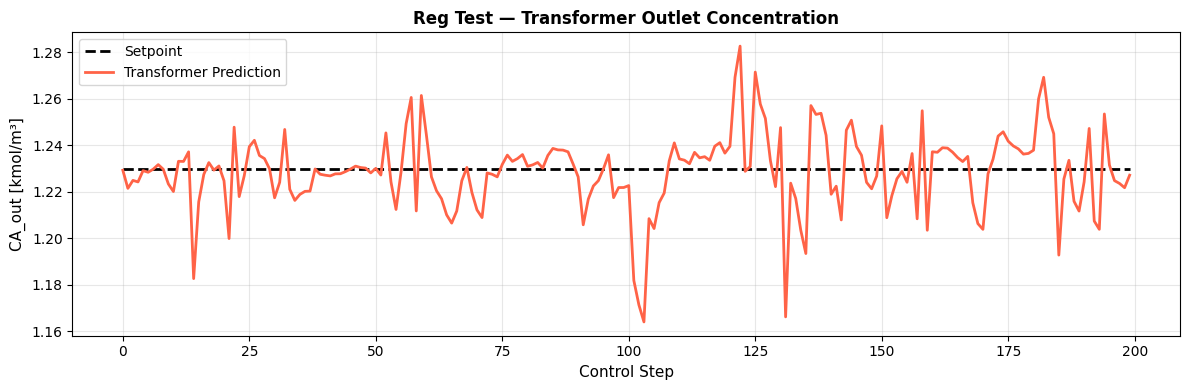

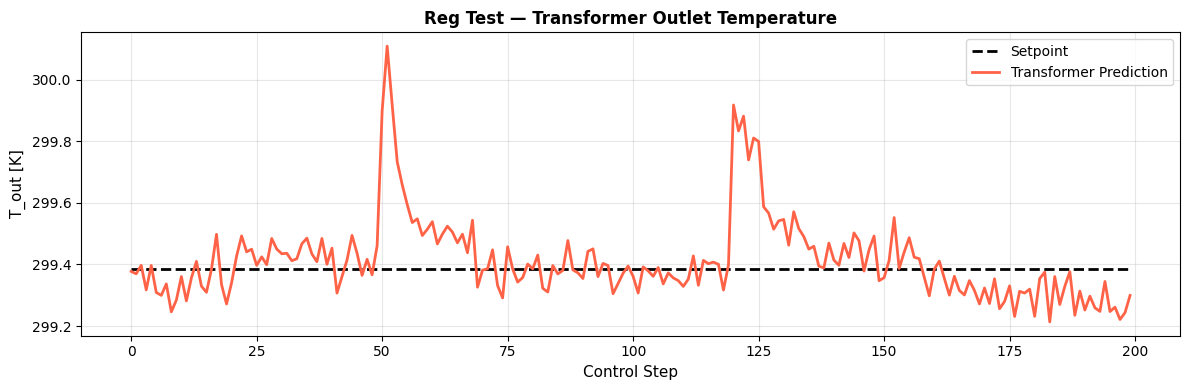

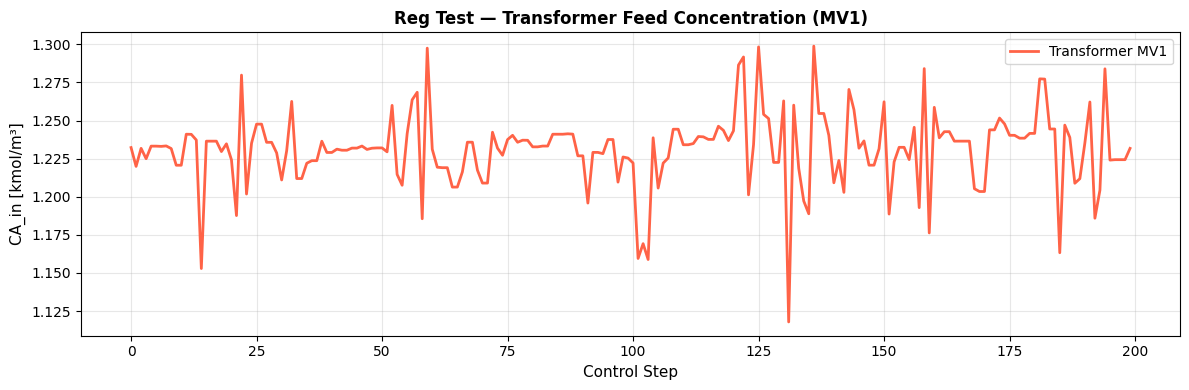

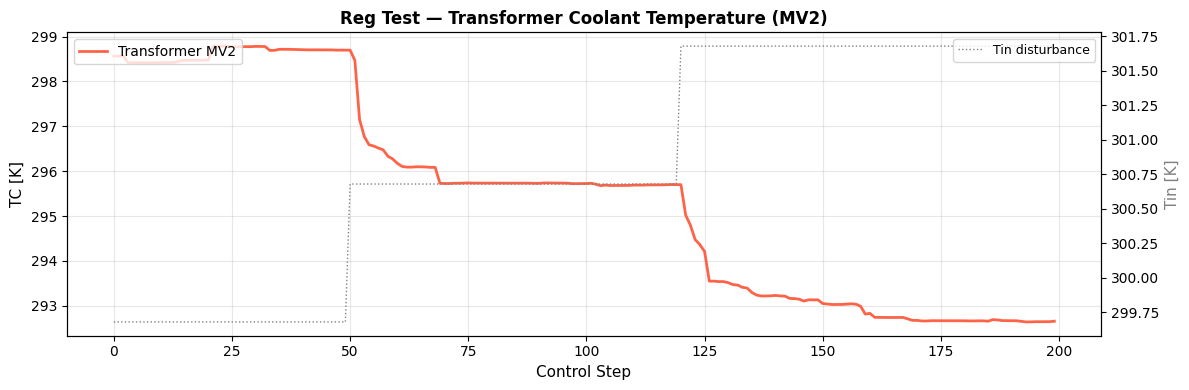

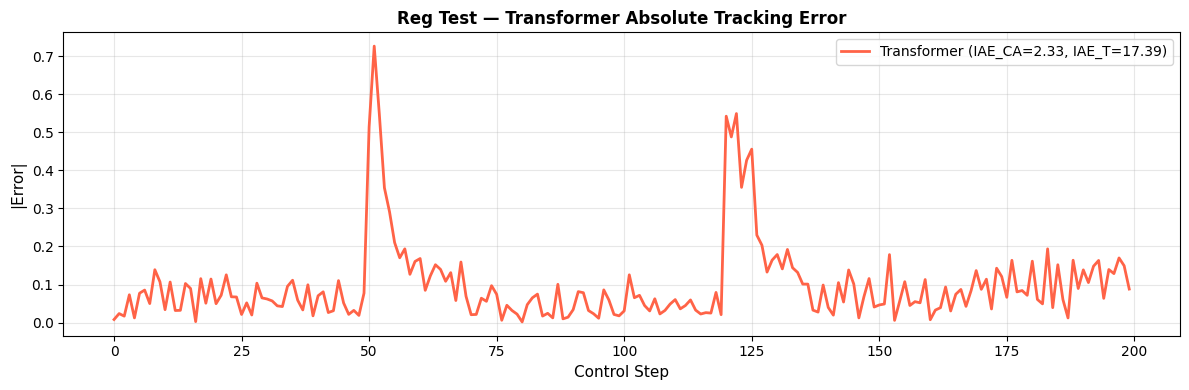

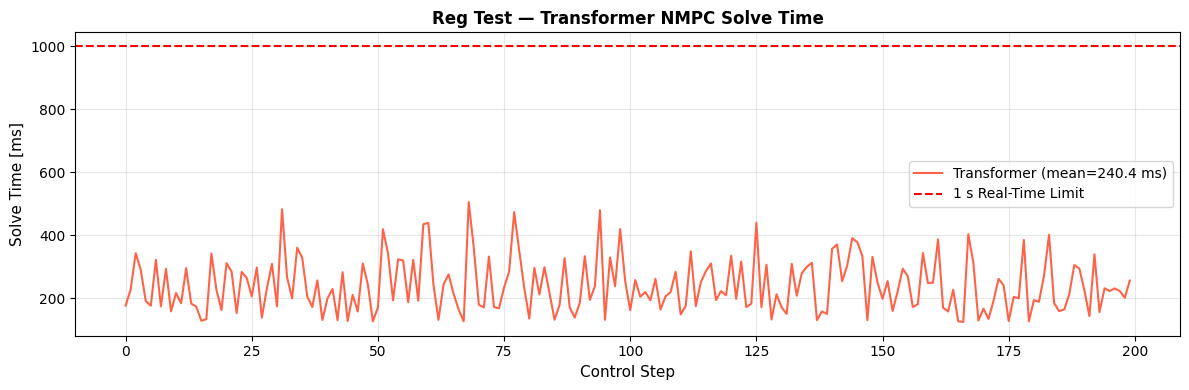

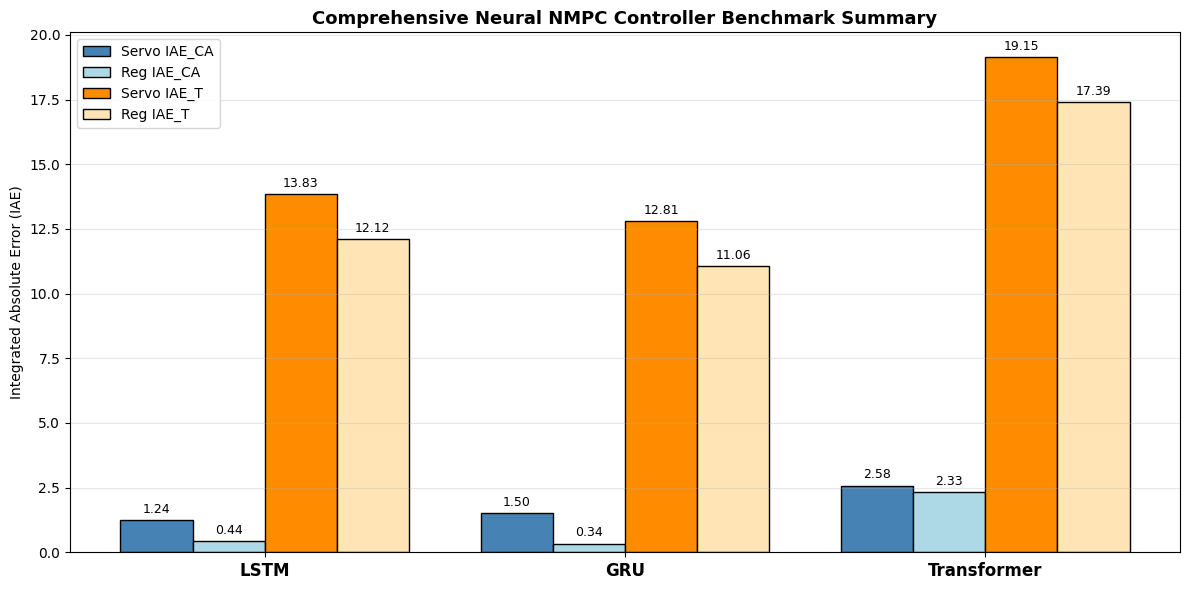

In [36]:
import matplotlib.pyplot as plt
import numpy as np

C = {"LSTM": "steelblue", "GRU": "seagreen", "Transformer": "tomato"}
LW = 2.0

# Helper function to save and display figures
def save_and_show(filename):
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()      # Display in notebook
    plt.close()     # Free memory


def save_individual_plots(results, SP, prefix, disturbance=None):
    steps_local = np.arange(len(results[0]["Y"]))

    for r in results:
        m_name = r["name"]
        m_color = C[m_name]

        print(f"\nGenerating plots for [{m_name}] ({prefix} test)...")

        # ======================================================
        # 1. CA_out
        # ======================================================
        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(steps_local, SP[:,0], "k--", lw=2, label="Setpoint")
        ax.plot(steps_local, r["Y"][:,0],
                color=m_color, lw=LW,
                label=f"{m_name} Prediction")
        ax.set_xlabel("Control Step", fontsize=11)
        ax.set_ylabel("CA_out [kmol/m³]", fontsize=11)
        ax.set_title(f"{prefix.capitalize()} Test — {m_name} Outlet Concentration",
                     fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
        save_and_show(f"{prefix}_{m_name}_CA_out.png")

        # ======================================================
        # 2. T_out
        # ======================================================
        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(steps_local, SP[:,1], "k--", lw=2, label="Setpoint")
        ax.plot(steps_local, r["Y"][:,1],
                color=m_color, lw=LW,
                label=f"{m_name} Prediction")
        ax.set_xlabel("Control Step", fontsize=11)
        ax.set_ylabel("T_out [K]", fontsize=11)
        ax.set_title(f"{prefix.capitalize()} Test — {m_name} Outlet Temperature",
                     fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
        save_and_show(f"{prefix}_{m_name}_T_out.png")

        # ======================================================
        # 3. CA_in (MV1)
        # ======================================================
        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(steps_local, r["U"][:,0],
                color=m_color, lw=LW,
                label=f"{m_name} MV1")
        ax.set_xlabel("Control Step", fontsize=11)
        ax.set_ylabel("CA_in [kmol/m³]", fontsize=11)
        ax.set_title(f"{prefix.capitalize()} Test — {m_name} Feed Concentration (MV1)",
                     fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
        save_and_show(f"{prefix}_{m_name}_CA_in.png")

        # ======================================================
        # 4. TC (MV2)
        # ======================================================
        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(steps_local, r["U"][:,1],
                color=m_color, lw=LW,
                label=f"{m_name} MV2")

        if disturbance is not None:
            ax2 = ax.twinx()
            ax2.plot(steps_local,
                     disturbance,
                     color="gray",
                     ls=":",
                     lw=1,
                     label="Tin disturbance")
            ax2.set_ylabel("Tin [K]", fontsize=11, color="gray")
            ax2.legend(loc="upper right", fontsize=9)

        ax.set_xlabel("Control Step", fontsize=11)
        ax.set_ylabel("TC [K]", fontsize=11)
        ax.set_title(f"{prefix.capitalize()} Test — {m_name} Coolant Temperature (MV2)",
                     fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left", fontsize=10)
        save_and_show(f"{prefix}_{m_name}_TC.png")

        # ======================================================
        # 5. Absolute Tracking Error
        # ======================================================
        fig, ax = plt.subplots(figsize=(12,4))

        err = np.sum(np.abs(r["Y"] - SP), axis=1)

        ax.plot(
            steps_local,
            err,
            color=m_color,
            lw=LW,
            label=f"{m_name} (IAE_CA={r['IAE_CA']:.2f}, IAE_T={r['IAE_T']:.2f})"
        )

        ax.set_xlabel("Control Step", fontsize=11)
        ax.set_ylabel("|Error|", fontsize=11)
        ax.set_title(f"{prefix.capitalize()} Test — {m_name} Absolute Tracking Error",
                     fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
        save_and_show(f"{prefix}_{m_name}_error.png")

        # ======================================================
        # 6. Solve Time
        # ======================================================
        fig, ax = plt.subplots(figsize=(12,4))

        ax.plot(
            steps_local,
            r["times"]*1000,
            color=m_color,
            lw=1.5,
            label=f"{m_name} (mean={r['times'].mean()*1000:.1f} ms)"
        )

        ax.axhline(
            1000,
            color="red",
            ls="--",
            lw=1.5,
            label="1 s Real-Time Limit"
        )

        ax.set_xlabel("Control Step", fontsize=11)
        ax.set_ylabel("Solve Time [ms]", fontsize=11)
        ax.set_title(f"{prefix.capitalize()} Test — {m_name} NMPC Solve Time",
                     fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
        save_and_show(f"{prefix}_{m_name}_solve_time.png")


# ======================================================
# Generate all plots
# ======================================================

save_individual_plots(
    servo_results,
    SP_servo,
    "servo"
)

save_individual_plots(
    reg_results,
    SP_reg,
    "reg",
    disturbance=TIN_dist
)

# ======================================================
# Comprehensive IAE Comparison
# ======================================================

fig, ax = plt.subplots(figsize=(12,6))

names = [r["name"] for r in servo_results]
x = np.arange(len(names))
width = 0.2

servo_iae_ca = [r["IAE_CA"] for r in servo_results]
servo_iae_t  = [r["IAE_T"] for r in servo_results]
reg_iae_ca   = [r["IAE_CA"] for r in reg_results]
reg_iae_t    = [r["IAE_T"] for r in reg_results]

b1 = ax.bar(x-1.5*width, servo_iae_ca, width,
            label="Servo IAE_CA",
            color="steelblue",
            edgecolor="black")

b2 = ax.bar(x-0.5*width, reg_iae_ca, width,
            label="Reg IAE_CA",
            color="lightblue",
            edgecolor="black")

b3 = ax.bar(x+0.5*width, servo_iae_t, width,
            label="Servo IAE_T",
            color="darkorange",
            edgecolor="black")

b4 = ax.bar(x+1.5*width, reg_iae_t, width,
            label="Reg IAE_T",
            color="moccasin",
            edgecolor="black")

for bars in [b1, b2, b3, b4]:
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=12, fontweight="bold")
ax.set_ylabel("Integrated Absolute Error (IAE)")
ax.set_title("Comprehensive Neural NMPC Controller Benchmark Summary",
             fontsize=13,
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend()

save_and_show("comprehensive_iae_comparison.png")

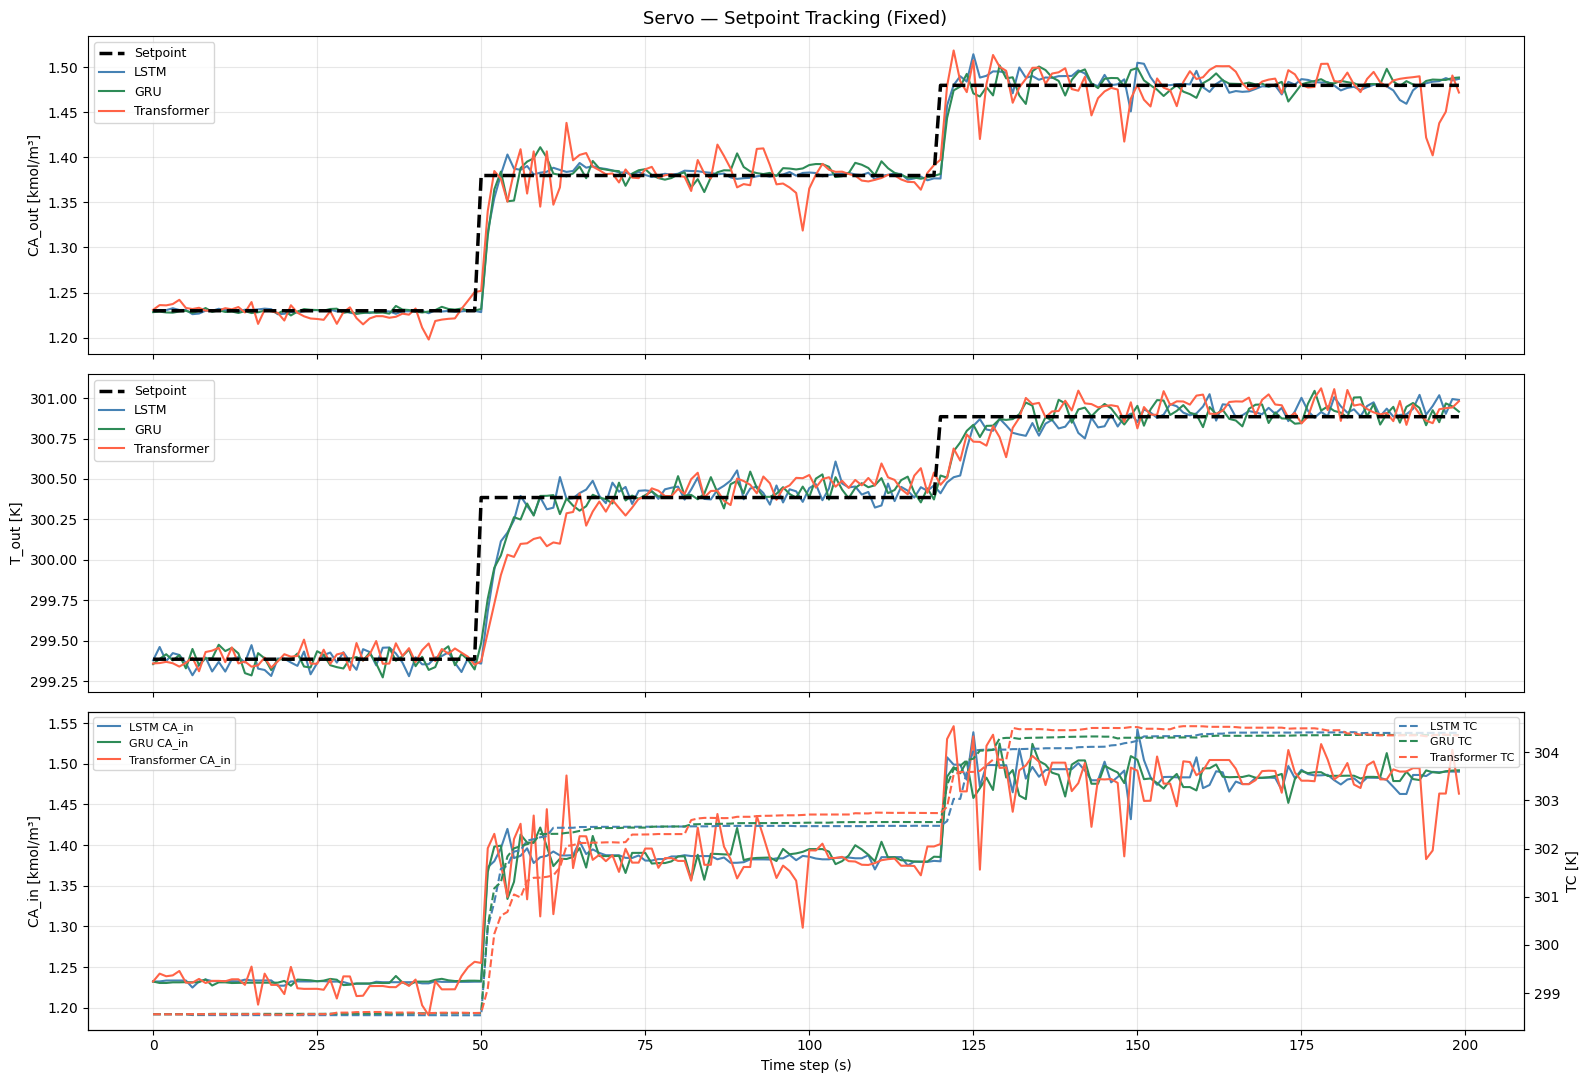

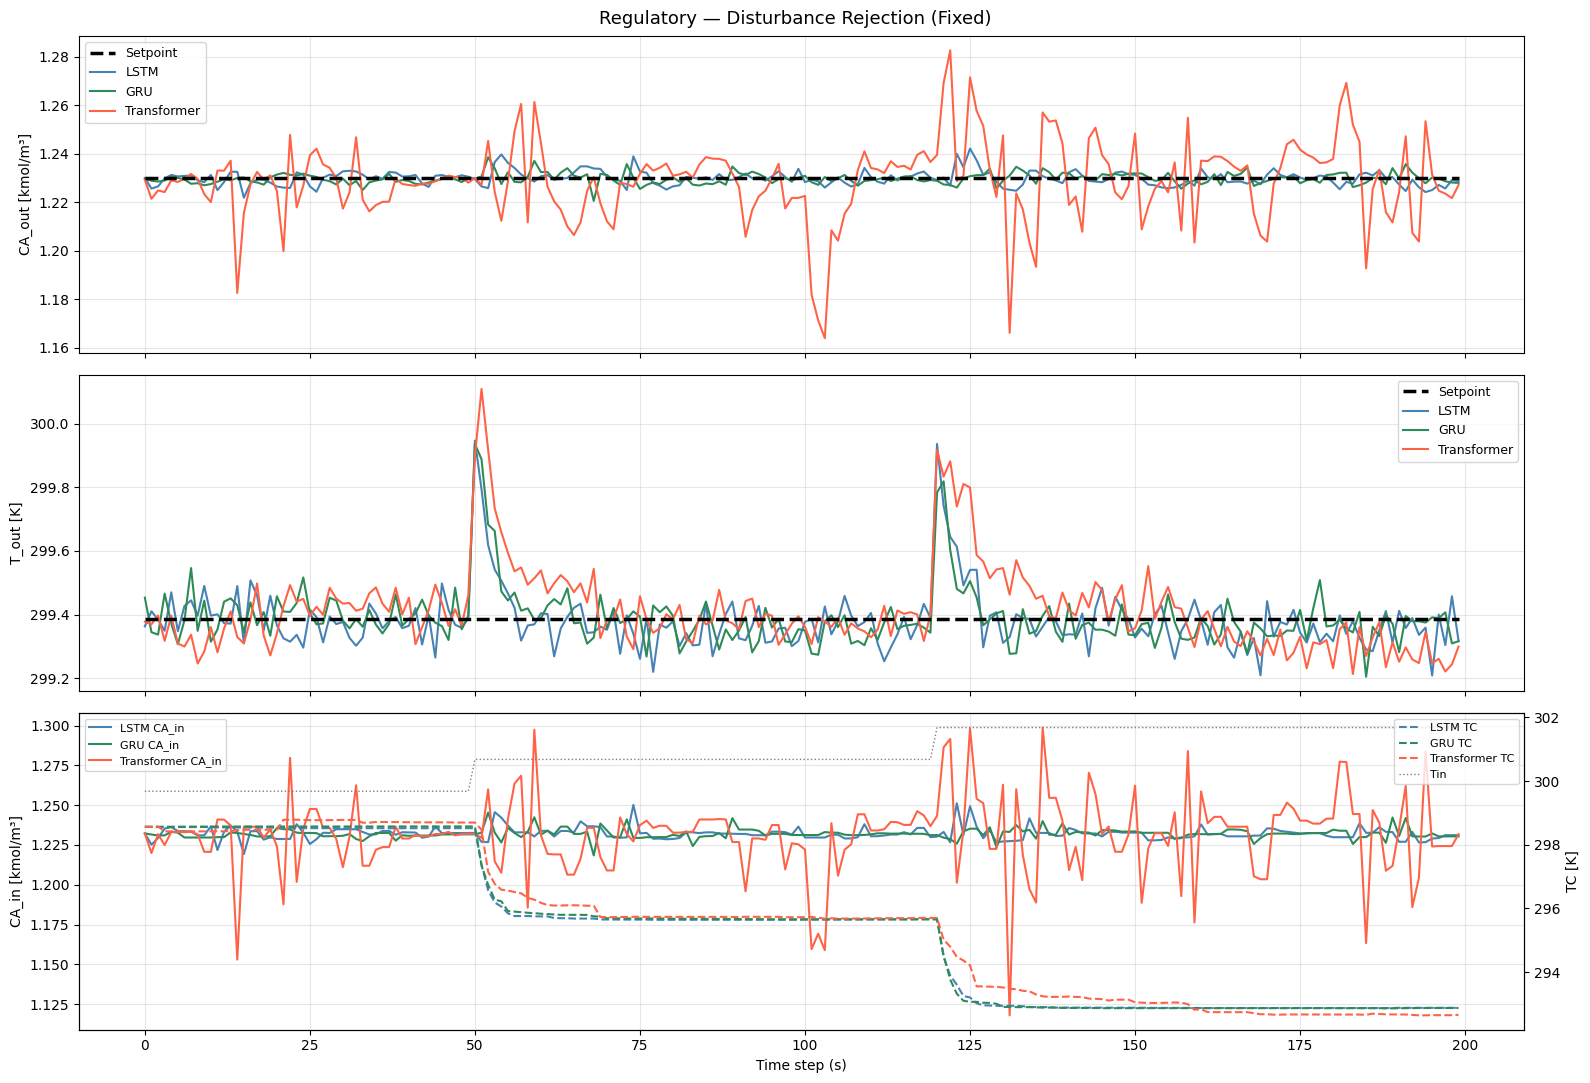

In [35]:
def plot_cl_combined(results, SP, title, disturbance=None):
    fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
    cols = ["steelblue","seagreen","tomato"]
    for i, ylabel in enumerate(["CA_out [kmol/m³]", "T_out [K]"]):
        axes[i].plot(SP[:,i], "k--", lw=2.5, label="Setpoint", zorder=5)
        for res, c in zip(results, cols):
            axes[i].plot(res["Y"][:,i], color=c, lw=1.5, label=res["name"])
        axes[i].set_ylabel(ylabel); axes[i].legend(fontsize=9); axes[i].grid(alpha=0.3)

    ax3 = axes[2]; ax3b = ax3.twinx()
    for res, c in zip(results, cols):
        ax3.plot(res["U"][:,0], color=c, lw=1.5, label=f"{res['name']} CA_in")
        ax3b.plot(res["U"][:,1], color=c, lw=1.5, ls="--", label=f"{res['name']} TC")
    ax3.set_ylabel("CA_in [kmol/m³]"); ax3b.set_ylabel("TC [K]")
    if disturbance is not None:
        ax3b.plot(disturbance, "gray", lw=1, ls=":", label="Tin")
    ax3.set_xlabel("Time step (s)")
    ax3.legend(loc="upper left", fontsize=8); ax3b.legend(loc="upper right", fontsize=8)
    ax3.grid(alpha=0.3)
    plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()

plot_cl_combined(servo_results, SP_servo, "Servo — Setpoint Tracking (Fixed)")
plot_cl_combined(reg_results, SP_reg, "Regulatory — Disturbance Rejection (Fixed)", disturbance=TIN_dist)